In [ ]:
# --- bootstrap: this notebook lives inside the module folder (graph_partitioning/),
# --- so hop to the repo root before importing, so `import graph_partitioning` and the
# --- repo-root-relative data paths (results/..., graph_partitioning/tests/...) resolve.
import os, sys, subprocess
_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("repo root:", _root)


# Hardware Calibration & Validation

Compare measured throughput from real RPis (via `sweep_inference.sh` and
hand-collected `bench-results.md` rows) against simulator predictions.

**Launch from the repo root with the venv active:**
```bash
source graph_partitioning/.venv/bin/activate
jupyter notebook hw_calibration.ipynb
```

**Sections**
1. Setup & imports
2. Real RPi network configuration (calibrated from llama-bench measurements)
3. Policy comparison on real network
4. Hardware vs simulator comparison (CSV sweeps + bench-results.md points)

*Synthetic-pool design exploration lives in `design_exploration.ipynb`.*


## 1. Setup

In [1]:
%matplotlib inline

from __future__ import annotations
import csv, datetime, os, sys

import matplotlib.pyplot as plt
import numpy as np

from graph_partitioning import Device, ModelSpec, Network, Simulator
from graph_partitioning.common import (
    CommunicationModel, PeerToPeerPolicy, CostModel, devices_from_profiles,
)
from graph_partitioning.logging_utils import setup_output_dir
from graph_partitioning.graph_plots import set_save_figures, set_show_figures
from graph_partitioning.sweep import (
    POLICY_COLOR, POLICY_RUNNERS,
    default_servers, run_all_policies_quiet, run_all_sweeps, scaled_model,
)
from graph_partitioning.analysis_plots import (
    plot_capacity_preset,
    plot_memory_timeline, plot_latency_timeline, plot_best_policy_timeline,
    sample_points as make_sample_points,
    TTFT_BUDGETS,
)

OUTPUT_ROOT = "sim_output"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Write the per-policy partition / comparison PDFs to disk? Turn OFF while
# iterating so a single run doesn't spray dozens of figures into sim_output/.
# (Inline display of those figures is controlled separately via
# set_show_figures(...) — see §3.)
SAVE_FIGS = False
set_save_figures(SAVE_FIGS)

print(f"Ready.  (SAVE_FIGS={SAVE_FIGS})")

2026-06-15 13:46:34 - graph_partitioning.model - INFO - setup_logger:64 - Logging to file: sim_output/model.log
2026-06-15 13:46:34 - graph_partitioning.policies.hybrid_pp_tp - INFO - setup_logger:64 - Logging to file: sim_output/hybrid_pp_tp.log
2026-06-15 13:46:34 - graph_partitioning.policies.metis - INFO - setup_logger:64 - Logging to file: sim_output/metis.log


Setting up console logging for logger: graph_partitioning.model
Setting up console logging for logger: graph_partitioning.graph_plots
Setting up console logging for logger: graph_partitioning.policies.hybrid_pp_tp
Setting up console logging for logger: graph_partitioning.policies.metis
Setting up console logging for logger: graph_partitioning.policies.msct
Setting up console logging for logger: graph_partitioning.compare_policies
Setting up console logging for logger: graph_partitioning.sweep
Ready.  (SAVE_FIGS=False)


## 2. Real RPi Network Configuration

Loads measured link data from `graph_partitioning/tests/pair_links_measured.csv`.
GFLOPS calibrated from single-RPi `llama-bench` (TinyLlama Q5_K_M, build 7f78f9c4 — see `bench-results.md`).

| measurement | value |
|---|---:|
| tg32  | 3.27 ± 0.06 tok/s |
| tg64  | 3.20 ± 0.05 tok/s |
| pp32  | 7.64 ± 0.14 tok/s |
| pp128 | 6.41 ± 0.51 tok/s |
| pp256 | 4.84 ± 0.23 tok/s |

Calibration formula (in code cell below): `gflops = tg_tps × per_token_flops / 1e9`.
Pipeline-mode and N-device numbers still pending — once `sweep_inference.sh --split-modes layer --counts "1 2 4 8"` finishes, Section 10 cross-checks the simulator's pipeline prediction against measured.

In [2]:
# num_layers = transformer blocks only (TinyLlama-1.1B has 22); the output
# head (-ngl 23 +1) is counted via embedding_weights_gb(), not as a block.
TINYLLAMA = ModelSpec(
    name="TinyLlama-1.1B",
    num_layers=22, num_heads=32, num_kv_heads=4,
    d_model=2048, d_k=64, d_ff=5632, vocab_size=32000,
)

LLAMA_7B = ModelSpec(
    name="Llama-7B",
    num_layers=32, num_heads=32, num_kv_heads=32,
    d_model=4096, d_k=128, d_ff=11008, vocab_size=32000,
)

LLAMA_13B = ModelSpec(
    name="Llama-13B",
    num_layers=40, num_heads=40, num_kv_heads=40,
    d_model=5120, d_k=128, d_ff=13824, vocab_size=32000,
)

MODEL_PRESETS = [("tinyllama", TINYLLAMA), ("llama-7b", LLAMA_7B), ("llama-13b", LLAMA_13B)]

In [3]:
# --- Calibration from real measurements ---
# Single-RPi 4B running TinyLlama-1.1B-Chat Q5_K_M, llama-bench build 7f78f9c4.
# tg = forward pass per generated token. The simulator's total_compute_flops()
# assumes FP32 dense compute; calibrating against the (quantised) Q5 measurement
# gives an "effective FP32-equivalent GFLOPS" — what the simulator should use to
# match real wall-clock latency.

MEASURED_TG_TPS_TINYLLAMA = (3.27 + 3.20) / 2   # tg32 and tg64 averaged

# This is per-token FLOPs (decode step); use seq_len=1 to match decode semantics.
_flops_per_token = TINYLLAMA.layer_compute_flops(1) * TINYLLAMA.num_layers
calibrated_gflops = MEASURED_TG_TPS_TINYLLAMA * _flops_per_token / 1e9

print(f"Measured tg: {MEASURED_TG_TPS_TINYLLAMA:.3f} tok/s")
print(f"TinyLlama per-token FLOPs (seq_len=1): {_flops_per_token / 1e9:.3f} GFLOPs")
print(f"→ Calibrated RPI_GFLOPS ≈ {calibrated_gflops:.2f}")
print(f"  Copy this value into RPI_GFLOPS in the cell below and re-run.")

Measured tg: 3.235 tok/s
TinyLlama per-token FLOPs (seq_len=1): 1.938 GFLOPs
→ Calibrated RPI_GFLOPS ≈ 6.27
  Copy this value into RPI_GFLOPS in the cell below and re-run.


In [4]:
# --- Coordinator (off-cluster driver, e.g. a Mac over the AP) ---
coordinator = Device("coordinator", gflops=100.0, memory_gb=16.0)

# --- RPi 4 Model B server pool ---
# Per-device compute cost can come from either cost model (see common.CostModel):
#   ROOFLINE -> measurement-driven: per-device R_compute (peak GFLOPS) + R_bw (memory
#               bandwidth) from the test-backend-ops dataset (parse_gflops.py), so
#               bandwidth-bound decode is realistic with no hand-tuning. HETEROGENEOUS.
#   GFLOPS   -> original single effective-GFLOPS per device (RPI_GFLOPS), back-solved
#               from measured tg in the calibration cell above. HOMOGENEOUS.
COST_MODEL   = CostModel.ROOFLINE     # <- flip to CostModel.GFLOPS for the old way
DEPLOY_QUANT = "q4_K"                  # which measured dtype's peak GFLOPS = R_compute
PROFILE_CSV  = "results/gflops/20260611_163608/device_profiles.csv"
# Treat the near-identical Pi 4B fleet as compute-homogeneous (every R_compute = fleet
# median). The per-board peak-GFLOPS spread is mostly thermal/measurement noise; left in,
# it makes pipeline prefill NON-MONOTONIC in device count (a 'faster' next board cancels a
# pipeline hop), which flattened the prefill-vs-N trend away from the measured decline.
# Flip to False only to model genuinely heterogeneous hardware.
UNIFORM_COMPUTE = True

RPI_GFLOPS    = 2.5    # used ONLY under CostModel.GFLOPS (see calibration cell)
RPI_MEM_GB    = 2.0    # 2 GB LPDDR4 (decimal GB); fallback when a profile row lacks mem
# Pi 4 microSD sequential-read ceiling ~40 MB/s; only matters once a model overflows DRAM.
RPI_SWAP_MBs  = 320.0  # ~= 40 MB/s

RPI_NAMES = [
    "rpi1",  "rpi2",  "rpi3",  "rpi4",  "rpi5",
    "rpi6",  "rpi7",  "rpi8",  "rpi9", "rpi13",
    "rpi15", "rpi16", "rpi17", "rpi19", "rpi20",
    "rpi22", "rpi24", "rpi25",
]

if COST_MODEL is CostModel.ROOFLINE:
    # peak GFLOPS = R_compute; R_bw + mem from the measured profile; keep RPI_NAMES order.
    _pool = {d.name: d for d in devices_from_profiles(
        PROFILE_CSV, quant=DEPLOY_QUANT, compute="peak",
        cost_model=CostModel.ROOFLINE, uniform_compute=UNIFORM_COMPUTE,
        default_mem_gb=RPI_MEM_GB, swap_bandwidth_mbps=RPI_SWAP_MBs)}
    missing = [n for n in RPI_NAMES if n not in _pool]
    if missing:
        print(f"\u26a0 not in profile (skipped): {missing}")
    servers = [_pool[n] for n in RPI_NAMES if n in _pool]
else:
    servers = [
        Device(name, gflops=RPI_GFLOPS, memory_gb=RPI_MEM_GB,
               swap_bandwidth_mbps=RPI_SWAP_MBs)
        for name in RPI_NAMES
    ]

# AP topology: all server-server traffic routes through the client.
net_real = Network(coordinator, servers, default_bw_mbps=50.0, default_rtt_ms=20.0)
net_real.set_pairwise_links(
    filename="graph_partitioning/tests/pair_links_measured.csv"
)
net_real.set_comm_config(
    communication_model=CommunicationModel.CLIENT_SERVER,
)
# llama.cpp's RPC backend achieves only ~15% of the iperf link bandwidth (calibrated
# in §10 vs measured sweeps). Without this, multi-device prefill is far too optimistic.
net_real.rpc_efficiency = 0.15

if COST_MODEL is CostModel.ROOFLINE:
    s = servers[0]
    print(f"Network: {len(servers)} RPis  |  cost model = roofline (measured)")
    print(f"  e.g. {s.name}: R_compute={s.gflops} GFLOPS, "
          f"R_bw={s.mem_bandwidth_gbps} GB/s, mem={s.memory_gb} GB")
else:
    print(f"Network: {len(servers)} RPis  |  {RPI_MEM_GB} GB RAM  |  "
          f"~{RPI_GFLOPS} GFLOPS (gflops cost model)")


Network: 18 RPis  |  cost model = roofline (measured)
  e.g. rpi1: R_compute=18.485 GFLOPS, R_bw=3.503 GB/s, mem=2.0 GB


### 2.1 GFLOPS vs ROOFLINE cost model

Both device pools use the **same measured peak GFLOPS** as `R_compute` — the only
difference is whether the roofline's bandwidth term (`bytes / R_bw`) is active.
Decode is memory-bound, so the compute-only `GFLOPS` model over-predicts throughput
~3×, while `ROOFLINE` matches the measured single-RPi `tg` to within a couple percent.
The roofline constants come from `test-backend-ops`, not fitted to this measurement.


2026-06-15 13:46:34 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:34 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:34 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries
2026-06-15 13:46:34 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:34 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:34 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries
2026-06-15 13:46:35 - graph_partitioning.model - INFO - build_computation_graph:433 - Building

Predicted single-token decode latency (s) - same peak GFLOPS for both:
cost_model  gflops  roofline
n_devices                   
1            0.174     0.232
2            0.195     0.251
4            0.237     0.292
8            0.323     0.377 

Single-RPi decode  -  measured 0.244s (4.1 tok/s)
  gflops   (compute-only): 0.174s (  5.7 tok/s)   measured/pred = 1.40
  roofline (+ R_bw)      : 0.232s (  4.3 tok/s)   measured/pred = 1.05


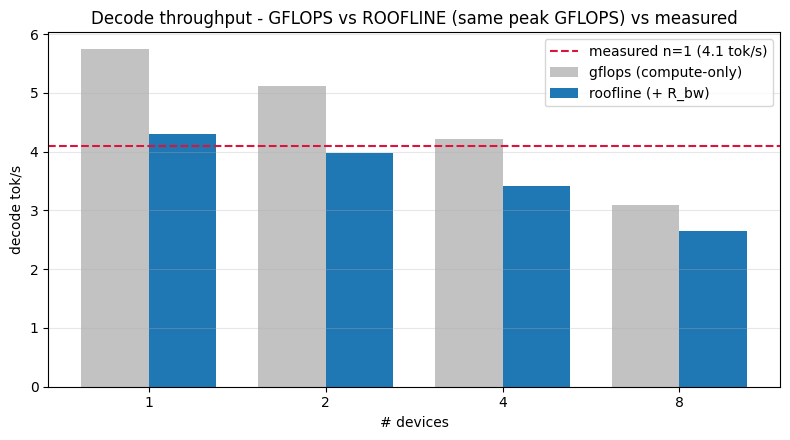

In [5]:
# === GFLOPS vs ROOFLINE — does the memory-bandwidth term matter? ===
# Both pools use the SAME measured peak GFLOPS as R_compute, so the ONLY difference is
# whether the roofline's bandwidth term (bytes / R_bw) is active. The roofline constants
# come from test-backend-ops, NOT fitted to this tg -> matching it is a real validation.
from graph_partitioning.policies.single_node import simulate_single_node
from graph_partitioning.policies.pipeline import simulate_pipeline
import pandas as pd

MEASURED_TG_S = 0.244          # measured single-RPi decode (local_rpi_coordinator, ngl23)
CMP_N_DEVICES = [1, 2, 4, 8]

def _cmp_pool(cost_model):
    pool = {d.name: d for d in devices_from_profiles(
        PROFILE_CSV, quant=DEPLOY_QUANT, compute="peak", cost_model=cost_model,
        default_mem_gb=RPI_MEM_GB, swap_bandwidth_mbps=RPI_SWAP_MBs)}
    return [pool[n] for n in RPI_NAMES if n in pool]

def _cmp_net(devs):
    net = Network(Device("client", gflops=100.0, memory_gb=16.0), devs,
                  default_bw_mbps=50.0, default_rtt_ms=20.0)
    net.set_pairwise_links(filename="graph_partitioning/tests/pair_links_measured.csv")
    net.set_comm_config(communication_model=CommunicationModel.CLIENT_SERVER)
    return net

_rows = []
for _label, _cm in [("gflops", CostModel.GFLOPS), ("roofline", CostModel.ROOFLINE)]:
    _devs = _cmp_pool(_cm)
    for _n in CMP_N_DEVICES:
        _runner = simulate_single_node if _n == 1 else simulate_pipeline
        _r = _runner(TINYLLAMA, _cmp_net(_devs[:_n]), seq_len=1, gen_tokens=1)
        _rows.append(dict(cost_model=_label, n_devices=_n, decode_s=_r["total_latency_s"]))

cmp_tbl = pd.DataFrame(_rows).pivot(index="n_devices", columns="cost_model", values="decode_s")
print("Predicted single-token decode latency (s) - same peak GFLOPS for both:")
print(cmp_tbl.round(3), "\n")
_g, _rf = cmp_tbl.loc[1, "gflops"], cmp_tbl.loc[1, "roofline"]
print(f"Single-RPi decode  -  measured {MEASURED_TG_S:.3f}s ({1/MEASURED_TG_S:.1f} tok/s)")
print(f"  gflops   (compute-only): {_g:.3f}s ({1/_g:5.1f} tok/s)   measured/pred = {MEASURED_TG_S/_g:.2f}")
print(f"  roofline (+ R_bw)      : {_rf:.3f}s ({1/_rf:5.1f} tok/s)   measured/pred = {MEASURED_TG_S/_rf:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
_x = np.arange(len(CMP_N_DEVICES)); _w = 0.38
ax.bar(_x - _w/2, 1.0/cmp_tbl["gflops"].values,   _w, label="gflops (compute-only)", color="#c2c2c2")
ax.bar(_x + _w/2, 1.0/cmp_tbl["roofline"].values, _w, label="roofline (+ R_bw)",      color="#1f77b4")
ax.axhline(1/MEASURED_TG_S, ls="--", color="crimson",
           label=f"measured n=1 ({1/MEASURED_TG_S:.1f} tok/s)")
ax.set(xticks=_x, xticklabels=CMP_N_DEVICES, xlabel="# devices", ylabel="decode tok/s",
       title="Decode throughput - GFLOPS vs ROOFLINE (same peak GFLOPS) vs measured")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Policy Comparison on Real Network

Runs every partitioning policy on the measured RPi network and plots the comparison.
Outputs go to `sim_output/<timestamp>/compare/`.

2026-06-15 13:46:36 - simulator.20260615_134636 - INFO - setup_logger:64 - Logging to file: sim_output/20260615_134636/simulator.log
2026-06-15 13:46:36 - simulator.20260615_134636 - INFO - plot_all_partitions:319 - ============================================================
2026-06-15 13:46:36 - simulator.20260615_134636 - INFO - plot_all_partitions:320 - Plotting partitions for all policies
2026-06-15 13:46:36 - simulator.20260615_134636 - INFO - plot_all_partitions:321 - ============================================================
2026-06-15 13:46:36 - graph_partitioning.compare_policies - INFO - plot_all_policies:460 - Running 7 policies (seq_len=128, gen_tokens=64); outputs -> sim_output/20260615_134636/compare
2026-06-15 13:46:36 - graph_partitioning.compare_policies - INFO - plot_all_policies:478 - === Running policy: single_node ===
2026-06-15 13:46:36 - graph_partitioning.compare_policies - INFO - plot_all_policies:478 - === Running policy: pipeline ===
2026-06-15 13:46:36 - 

Setting up console logging for logger: simulator.20260615_134636


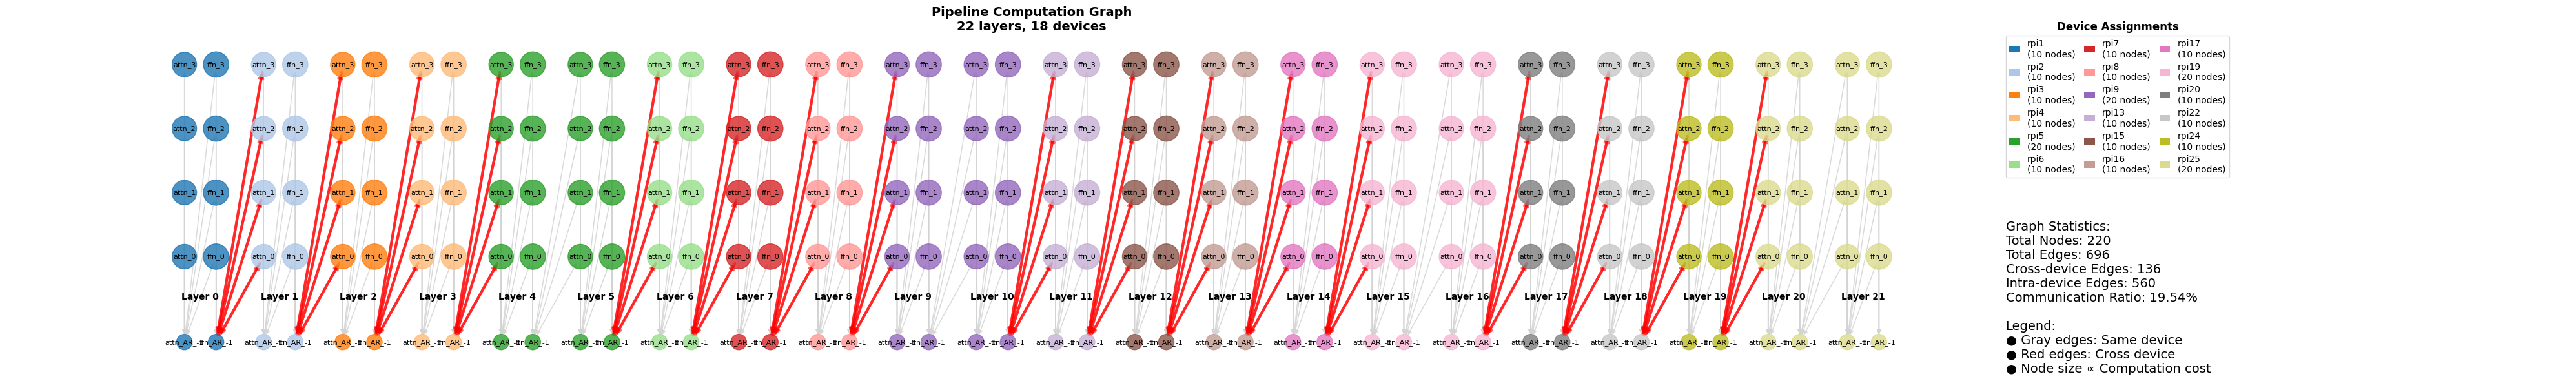

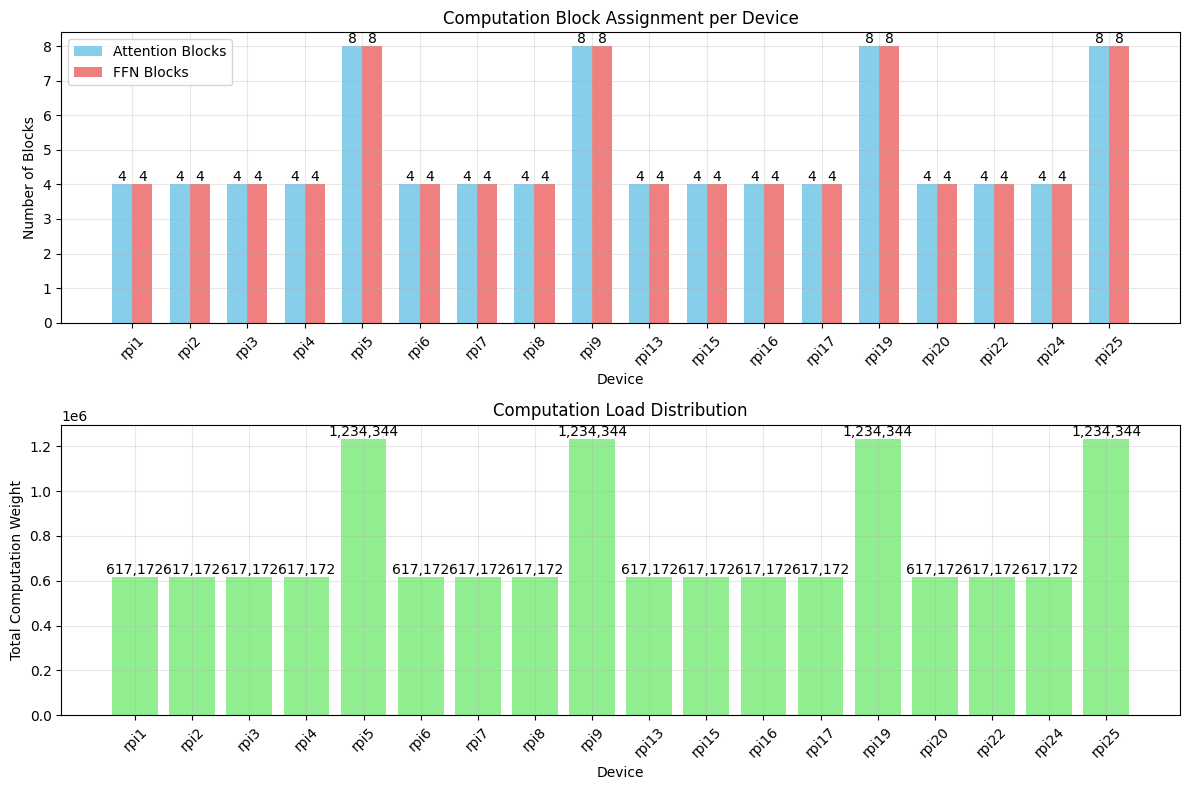

2026-06-15 13:46:37 - graph_partitioning.compare_policies - INFO - plot_all_policies:478 - === Running policy: tensor ===
2026-06-15 13:46:37 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:37 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:37 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries


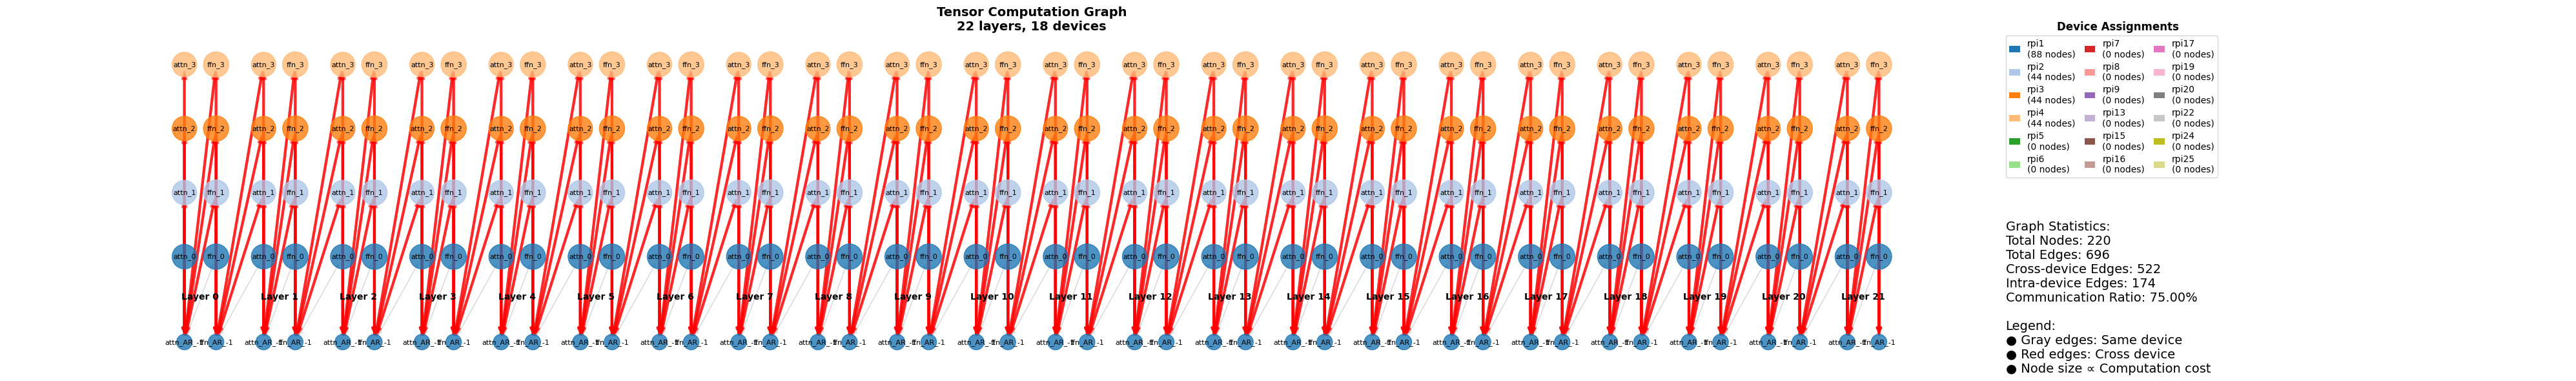

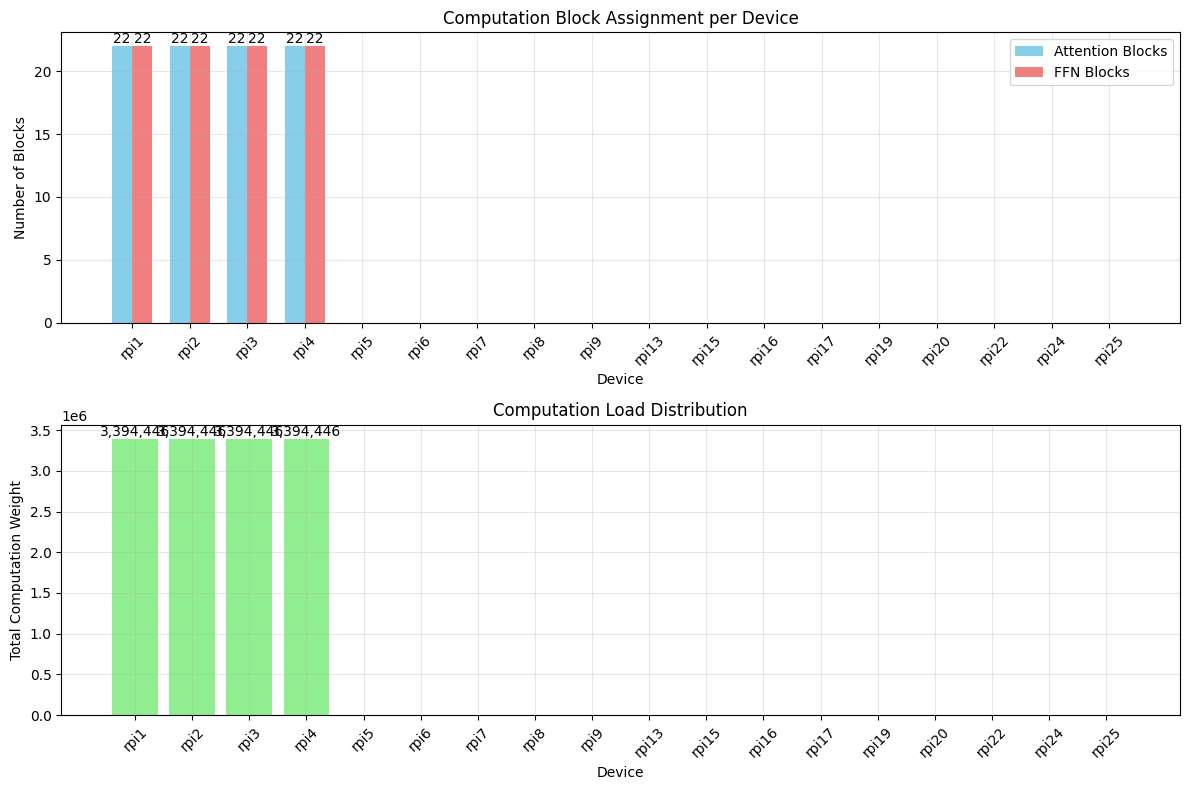

2026-06-15 13:46:38 - graph_partitioning.compare_policies - INFO - plot_all_policies:478 - === Running policy: metis ===
2026-06-15 13:46:38 - graph_partitioning.policies.metis - INFO - metis_partition_computation_blocks:277 - Starting METIS partitioning
2026-06-15 13:46:38 - graph_partitioning.policies.metis - INFO - metis_partition_computation_blocks:280 - Partitioning into 18 parts for 18 devices
2026-06-15 13:46:38 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:38 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:38 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries
2026-06-15 13:46:38 - graph_partitioning.policies.metis - INFO - device_constraints_for_metis:192 - Device rpi1 (18.485GFLOPs, 2.0GB, 691.39Mbps

Resource: Compute, Total: 332.73, Allocations: [332.73   0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.     0.     0.  ]
Resource: Memory, Total: 0.73732194304, Allocations: [0.73732194 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]
Resource: Network, Total: 11634.07, Allocations: [11634.07     0.       0.       0.       0.       0.       0.       0.
     0.       0.       0.       0.       0.       0.       0.       0.
     0.       0.  ]


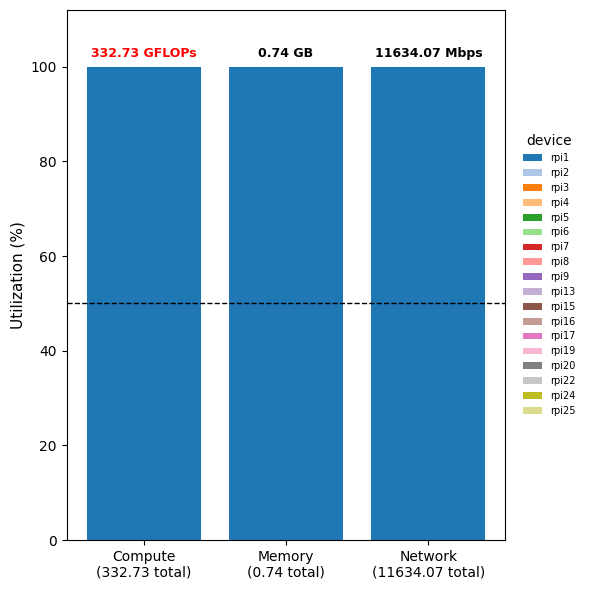

2026-06-15 13:46:38 - graph_partitioning.policies.metis - INFO - device_constraints_for_metis:256 - Device shares: [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
2026-06-15 13:46:38 - graph_partitioning.policies.metis - INFO - metis_partition_computation_blocks:309 - Device capacity weights: ['rpi1=1.000', 'rpi2=0.000', 'rpi3=0.000', 'rpi4=0.000', 'rpi5=0.000', 'rpi6=0.000', 'rpi7=0.000', 'rpi8=0.000', 'rpi9=0.000', 'rpi13=0.000', 'rpi15=0.000', 'rpi16=0.000', 'rpi17=0.000', 'rpi19=0.000', 'rpi20=0.000', 'rpi22=0.000', 'rpi24=0.000', 'rpi25=0.000']
2026-06-15 13:46:38 - graph_partitioning.policies.metis - INFO - metis_partition_computation_blocks:337 - Running METIS with 1/18 devices (kept indices: [0])
2026-06-15 13:46:38 - graph_partitioning.policies.metis - INFO - metis_partition_computation_blocks:357 - METIS partitioning completed successfully


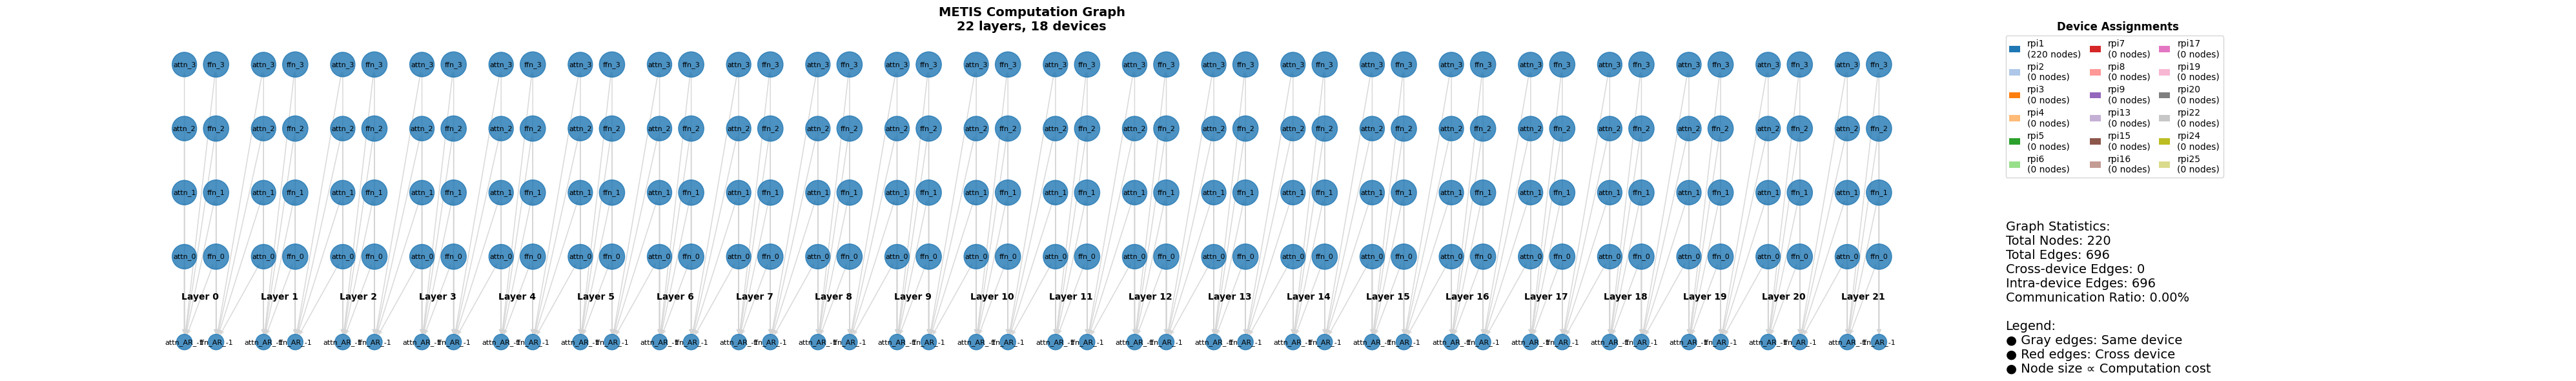

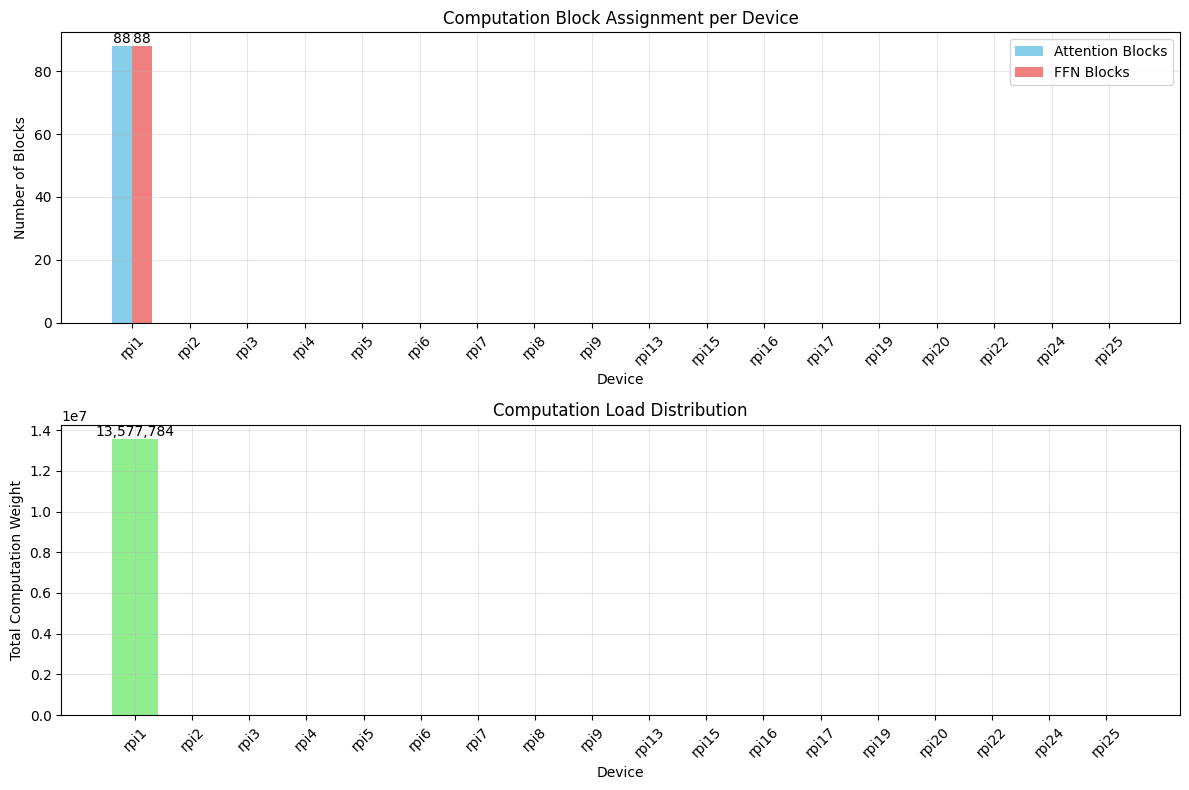

2026-06-15 13:46:39 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:39 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:39 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries
2026-06-15 13:46:39 - graph_partitioning.policies.metis - INFO - simulate_metis:710 - Communication analysis: 0 cross-partition edges
2026-06-15 13:46:39 - graph_partitioning.compare_policies - INFO - plot_all_policies:478 - === Running policy: alpa ===
2026-06-15 13:46:39 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:39 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:39 - graph_pa

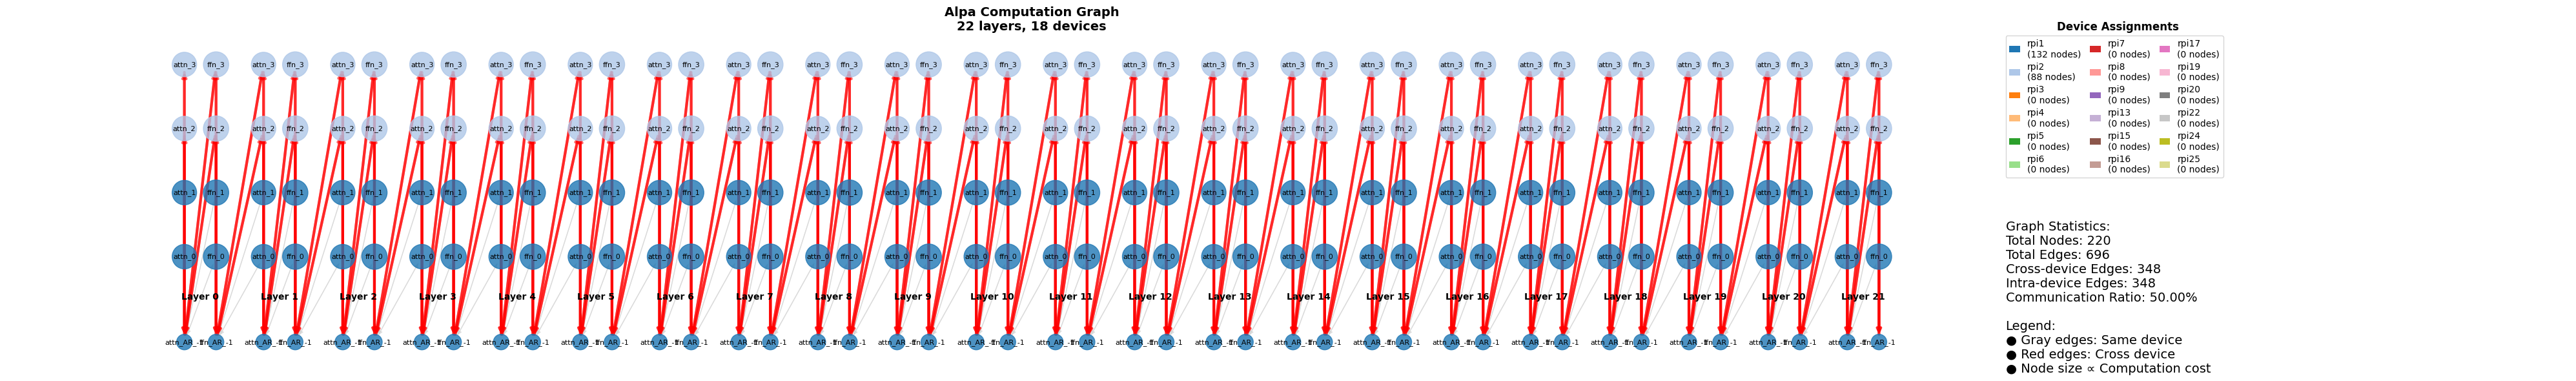

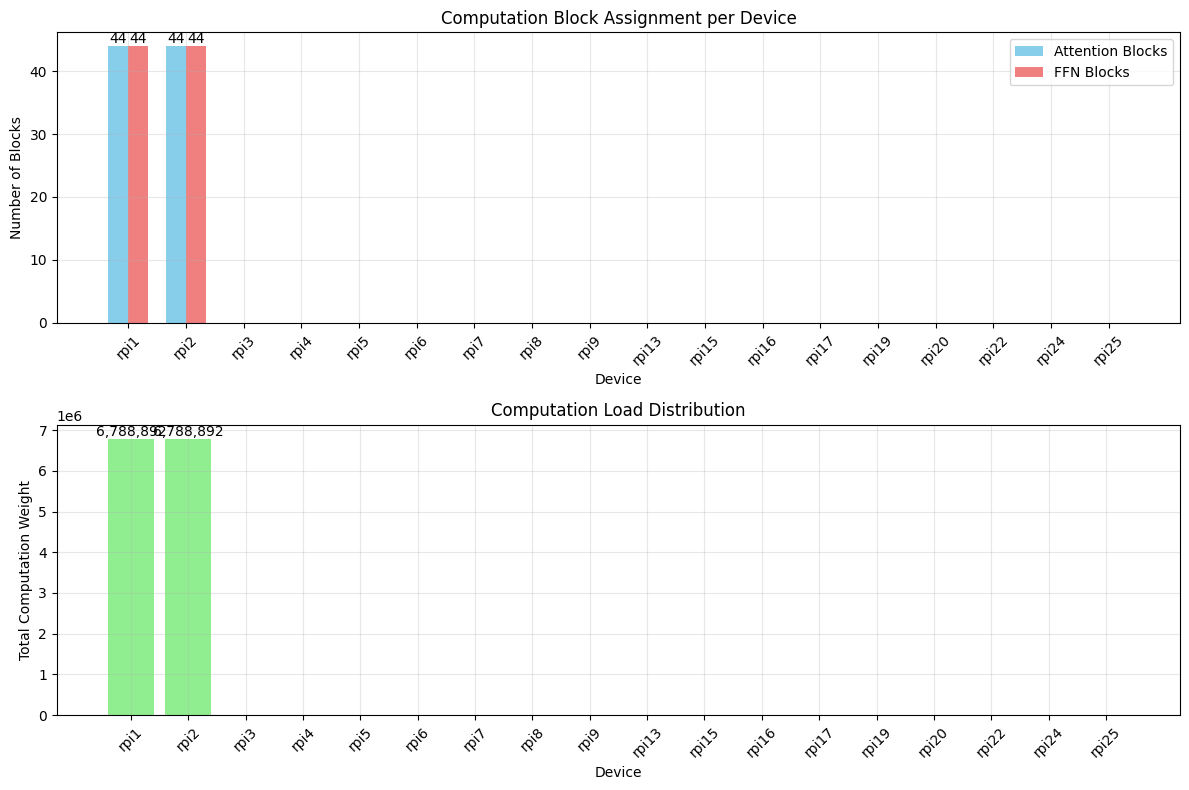

2026-06-15 13:46:40 - graph_partitioning.compare_policies - INFO - plot_all_policies:478 - === Running policy: hybrid_pp_tp ===
2026-06-15 13:46:40 - graph_partitioning.policies.hybrid_pp_tp - INFO - simulate_hybrid_pp_tp:162 - Starting hybrid_pp_tp partitioning
2026-06-15 13:46:40 - graph_partitioning.policies.hybrid_pp_tp - INFO - simulate_hybrid_pp_tp:197 - hybrid_pp_tp: 1 stage(s), tensor degrees [1], layer counts [22]
2026-06-15 13:46:40 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:40 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:40 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries


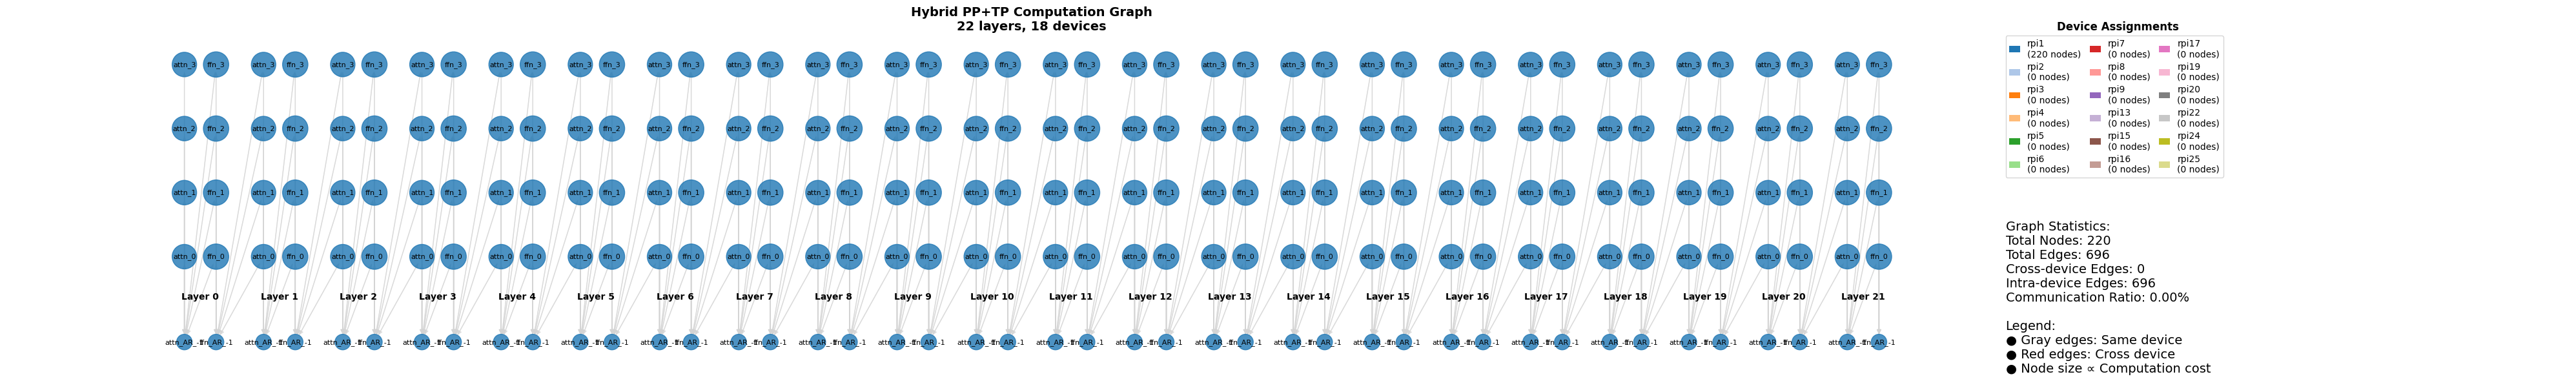

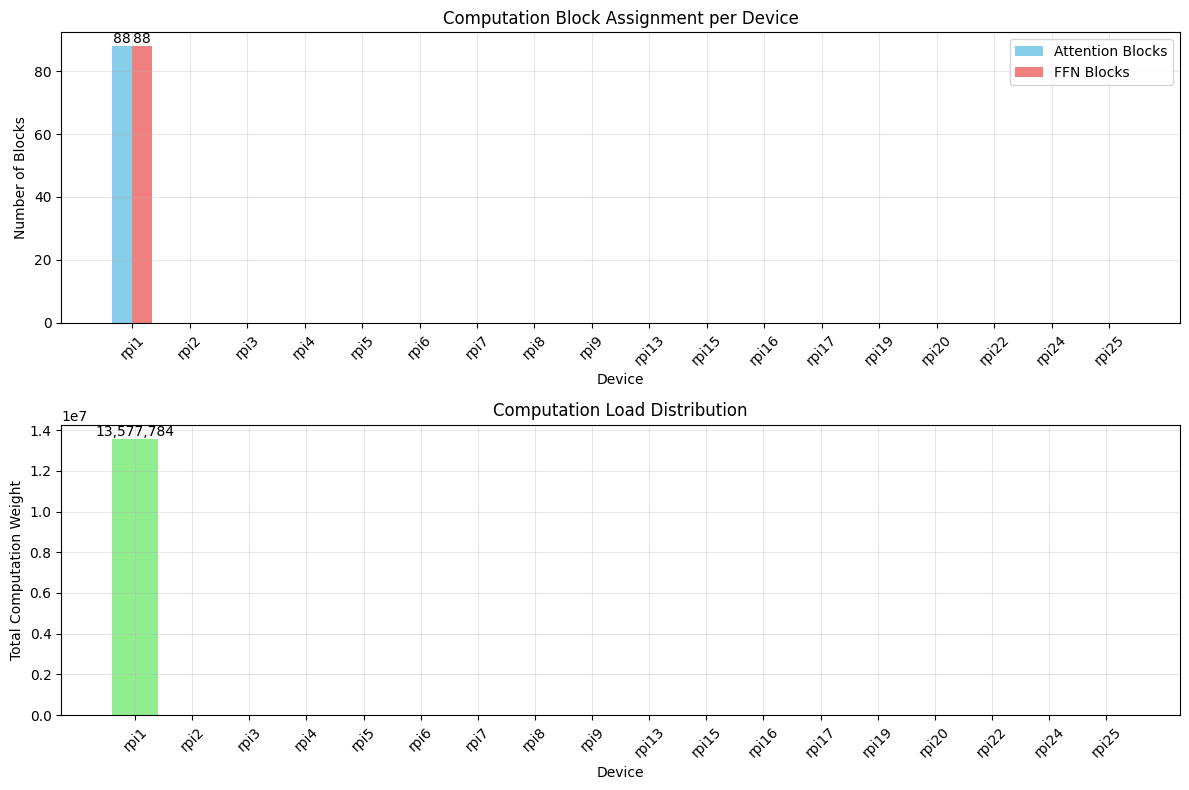

2026-06-15 13:46:41 - graph_partitioning.compare_policies - INFO - plot_all_policies:478 - === Running policy: msct ===
2026-06-15 13:46:41 - graph_partitioning.policies.msct - INFO - simulate_msct:325 - m-SCT: 176 ops across 4/18 devices, 87 favorite-child co-locations, makespan 28.0355s
2026-06-15 13:46:41 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:41 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:41 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries


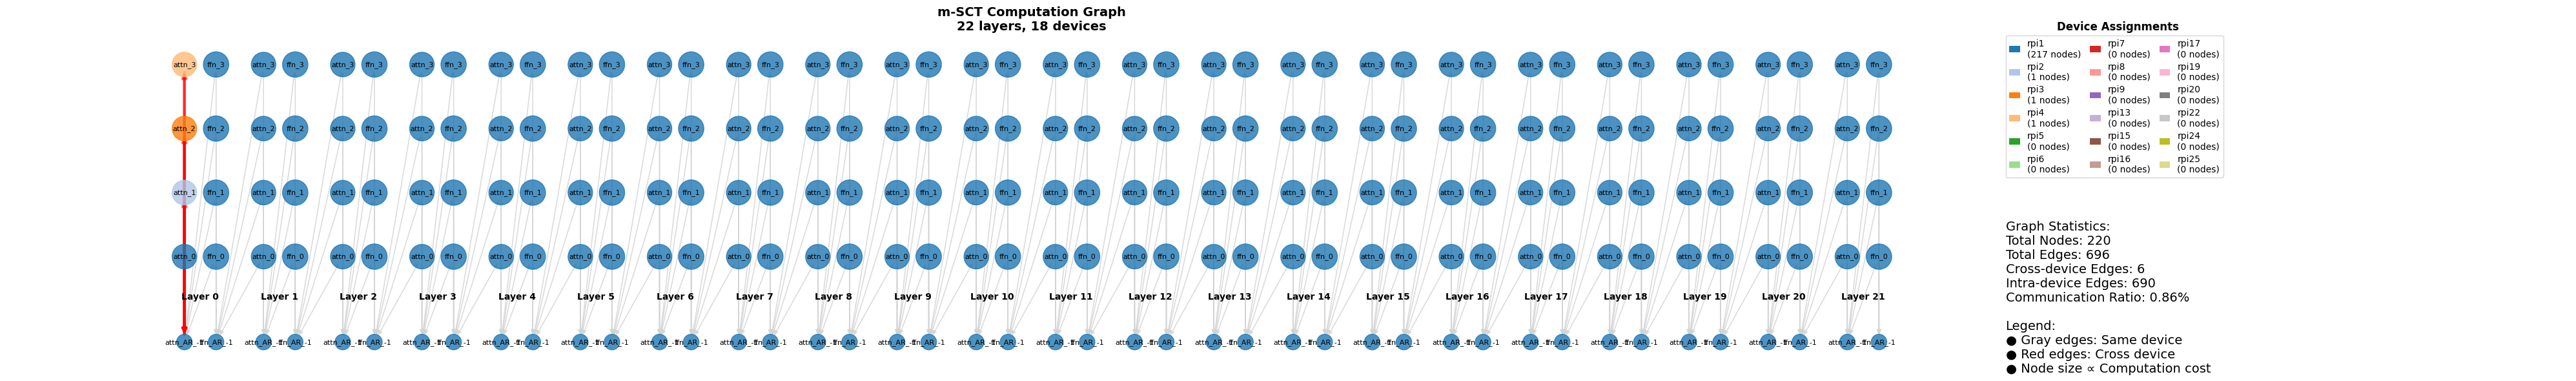

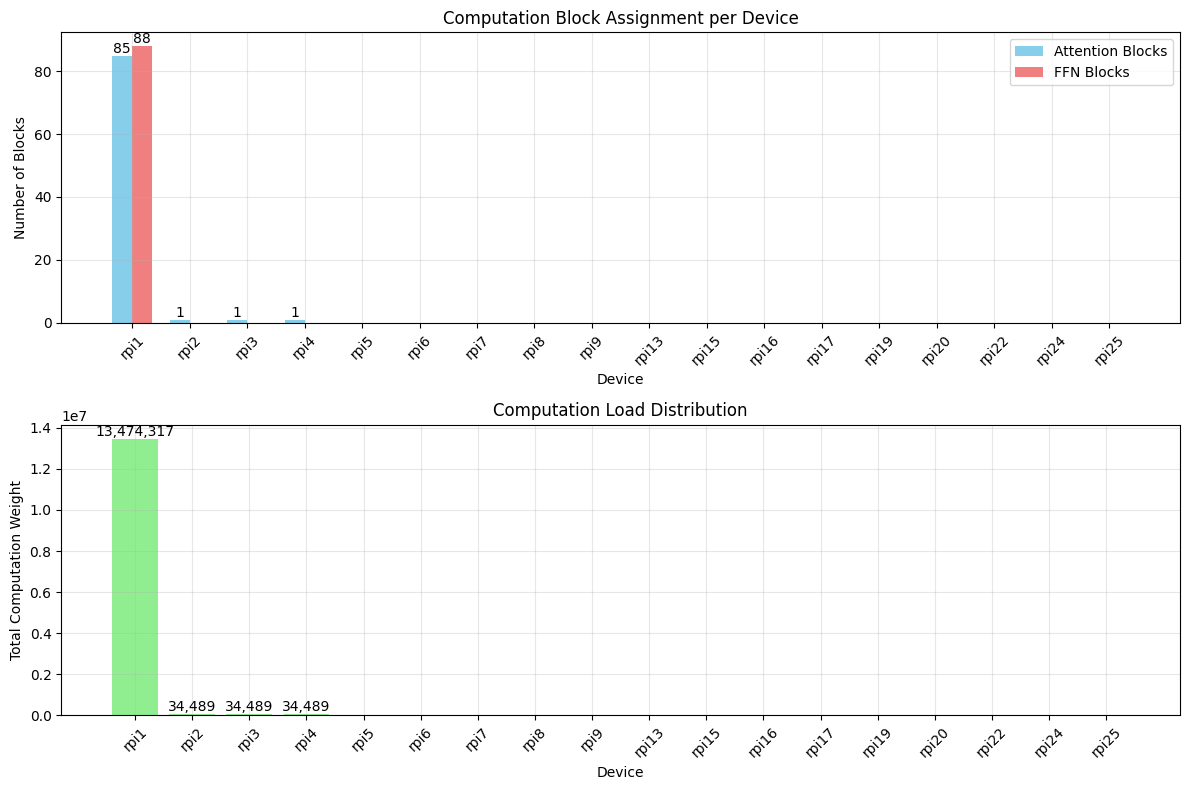

2026-06-15 13:46:42 - graph_partitioning.compare_policies - INFO - plot_all_policy_partitions:247 - Saved policy partition comparison to sim_output/20260615_134636/compare/policy_partition_heatmaps.pdf


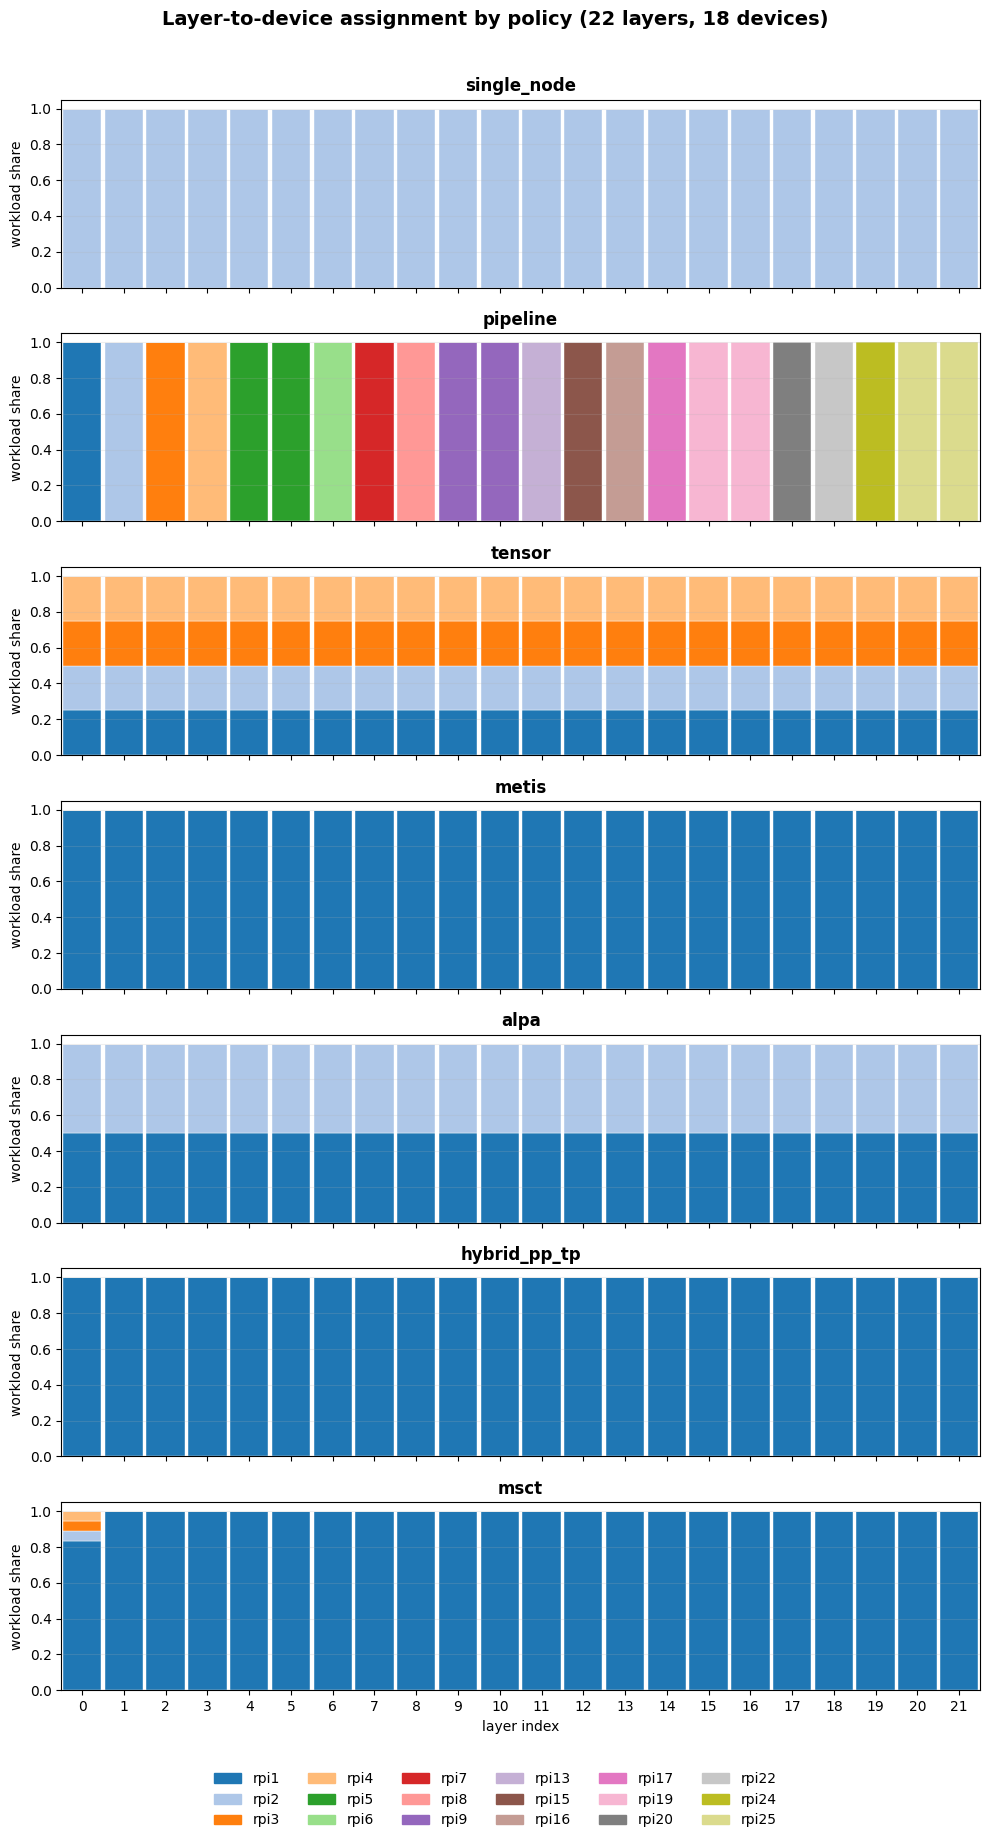

2026-06-15 13:46:43 - graph_partitioning.compare_policies - INFO - plot_latency_comparison:281 - Saved per-policy latency comparison to sim_output/20260615_134636/compare/policy_latency_comparison.pdf


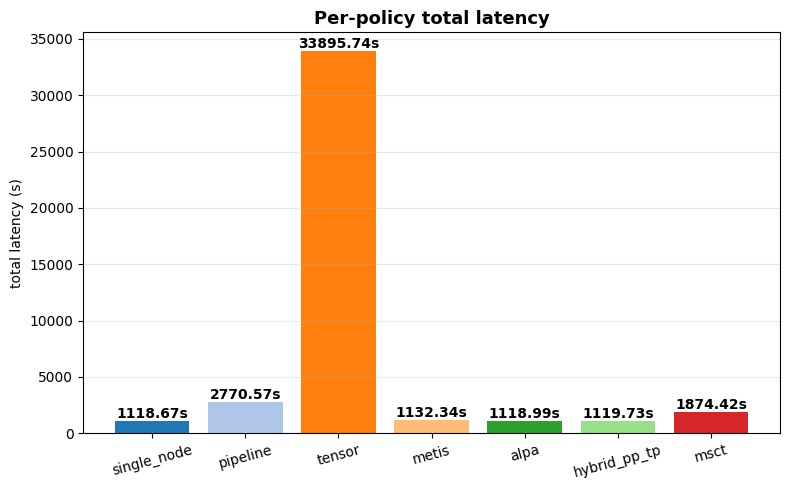

2026-06-15 13:46:43 - graph_partitioning.compare_policies - INFO - plot_device_workload_share:350 - Saved device workload share to sim_output/20260615_134636/compare/policy_device_workload_share.pdf


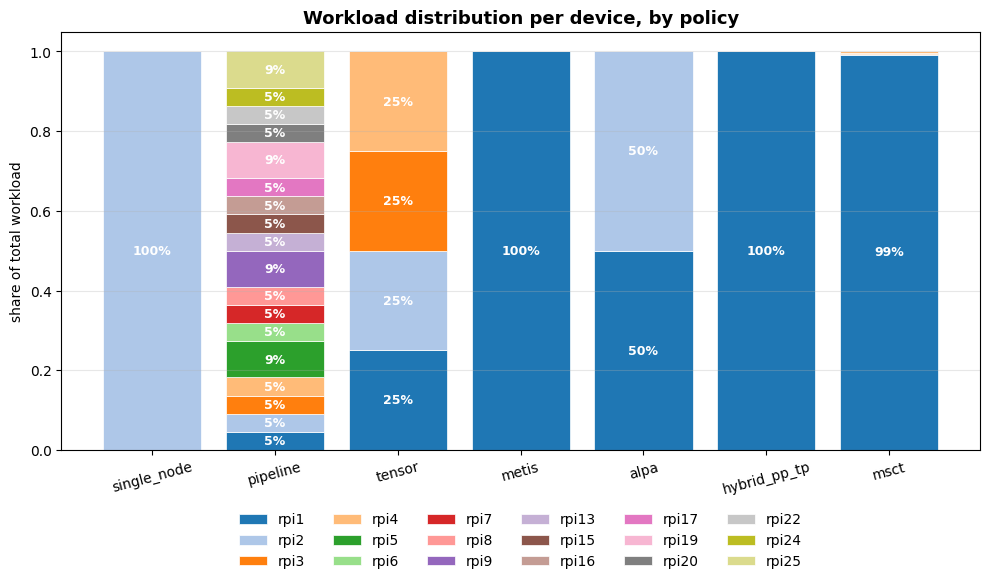

2026-06-15 13:46:43 - graph_partitioning.compare_policies - INFO - plot_all_policies:532 - Wrote comparison artefacts to sim_output/20260615_134636/compare
2026-06-15 13:46:43 - simulator.20260615_134636 - INFO - plot_all_partitions:338 - Comparison plots written to sim_output/20260615_134636/compare


Outputs in sim_output/20260615_134636/


In [6]:
model    = TINYLLAMA
seq_len  = 128
gen_toks = 64

timestamp  = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir    = f"{OUTPUT_ROOT}/{timestamp}"

# Show each policy's partition graph + device-workload breakdown inline here.
# Turned back off afterwards so the bulk simulate_* loop in §10 doesn't flood
# the output with per-prediction figures.
set_show_figures(True)
sim = Simulator(net_real, model, out_dir)
sim.plot_all_partitions(seq_len=seq_len, gen_tokens=gen_toks)
set_show_figures(False)
print(f"Outputs in {out_dir}/")

## 10. Hardware vs Simulator Comparison

Pulls measured throughput from two sources and compares against simulator
predictions:

1. **`results/sweep_*.csv`** — full N-device sweeps from `sweep_inference.sh`.
   The filename suffix (`mac_coordinator`, `local_rpi_coordinator`, …)
   identifies the coordinator placement.
2. **`bench-results.md`** — individual single-RPi and 2-RPi measurements
   collected by hand. These are mirrored into `BENCH_MD_POINTS` below; when
   you add a row to the markdown, append it here too.

**Cleanup steps:**
- Each row is tagged with a `scenario` (and a `ngl` for bench-md rows so they
  stay distinguishable).
- Older `sweep_inference.sh` runs produced `4×n_devices` duplicate rows per
  group because of a `,` vs `/` semantics bug in llama-bench's `-ts` flag
  (`,` triggered a *sweep over* the values instead of the intended *single
  config split with `/`*). The load cell averages over duplicates; the
  `n_samples` column reports how many rows collapsed into each entry.

**Coordinator placement** is the headline comparison: with an RPi as
coordinator, all server↔server traffic stays inside the RPi mesh; with the
Mac as coordinator, every layer transfer traverses Mac↔AP↔RPi. The simulator
currently treats all configs as `CLIENT_SERVER` (AP-routed), so the
discrepancy between Mac-coord and RPi-coord measurements is the calibration
gap the simulator needs to close.

In [7]:
# Supplementary point measurements from bench-results.md.
# Each entry is one row of a llama-bench table. Keep this list in sync with
# the markdown file — when you add a measurement there, add it here too.
#
# Conventions:
#   - tps  is t/s as reported by llama-bench.
#   - test = "pp{N}"  → prefill on N prompt tokens (n_prompt=N, n_gen=0).
#   - test = "tg{N}"  → decode N tokens         (n_prompt=0, n_gen=N).
#   - n_devices counts *backend* devices (excluding the coordinator if the
#     coordinator also runs inference locally).

BENCH_MD_POINTS = [
    # ── Coordinator: rpi2 → rpi1 via RPC, varying ngl (offload depth) ──
    dict(scenario="rpi2_coord_1rpc", ngl=3,  n_devices=1, test="pp32",  tps=7.05),
    dict(scenario="rpi2_coord_1rpc", ngl=3,  n_devices=1, test="pp128", tps=7.20),
    dict(scenario="rpi2_coord_1rpc", ngl=3,  n_devices=1, test="pp256", tps=5.95),
    dict(scenario="rpi2_coord_1rpc", ngl=3,  n_devices=1, test="tg32",  tps=3.29),
    dict(scenario="rpi2_coord_1rpc", ngl=3,  n_devices=1, test="tg64",  tps=3.22),

    dict(scenario="rpi2_coord_1rpc", ngl=11, n_devices=1, test="pp32",  tps=7.25),
    dict(scenario="rpi2_coord_1rpc", ngl=11, n_devices=1, test="pp128", tps=7.01),
    dict(scenario="rpi2_coord_1rpc", ngl=11, n_devices=1, test="pp256", tps=6.72),
    dict(scenario="rpi2_coord_1rpc", ngl=11, n_devices=1, test="tg32",  tps=2.93),
    dict(scenario="rpi2_coord_1rpc", ngl=11, n_devices=1, test="tg64",  tps=2.93),

    dict(scenario="rpi2_coord_1rpc", ngl=99, n_devices=1, test="pp32",  tps=6.52),
    dict(scenario="rpi2_coord_1rpc", ngl=99, n_devices=1, test="pp128", tps=6.68),
    dict(scenario="rpi2_coord_1rpc", ngl=99, n_devices=1, test="pp256", tps=5.01),
    dict(scenario="rpi2_coord_1rpc", ngl=99, n_devices=1, test="tg32",  tps=2.33),
    dict(scenario="rpi2_coord_1rpc", ngl=99, n_devices=1, test="tg64",  tps=2.32),

    # ── rpi2 standalone (no RPC) ──
    dict(scenario="rpi2_local", ngl=11, n_devices=1, test="pp32",  tps=7.93),
    dict(scenario="rpi2_local", ngl=11, n_devices=1, test="pp128", tps=7.40),
    dict(scenario="rpi2_local", ngl=11, n_devices=1, test="pp256", tps=5.61),
    dict(scenario="rpi2_local", ngl=11, n_devices=1, test="tg32",  tps=3.86),
    dict(scenario="rpi2_local", ngl=11, n_devices=1, test="tg64",  tps=3.75),

    dict(scenario="rpi2_local", ngl=99, n_devices=1, test="pp32",  tps=7.92),
    dict(scenario="rpi2_local", ngl=99, n_devices=1, test="pp128", tps=7.70),
    dict(scenario="rpi2_local", ngl=99, n_devices=1, test="pp256", tps=6.02),
    dict(scenario="rpi2_local", ngl=99, n_devices=1, test="tg32",  tps=3.92),
    dict(scenario="rpi2_local", ngl=99, n_devices=1, test="tg64",  tps=3.88),

    # ── rpi1 standalone (no RPC) — used as the calibration baseline ──
    dict(scenario="rpi1_local", ngl=99, n_devices=1, test="pp32",  tps=7.64),
    dict(scenario="rpi1_local", ngl=99, n_devices=1, test="pp128", tps=6.41),
    dict(scenario="rpi1_local", ngl=99, n_devices=1, test="pp256", tps=4.84),
    dict(scenario="rpi1_local", ngl=99, n_devices=1, test="tg32",  tps=3.27),
    dict(scenario="rpi1_local", ngl=99, n_devices=1, test="tg64",  tps=3.20),

    # ── Mac coord → 2 RPis (rpi1, rpi2) via RPC, ngl=3, close to AP ──
    dict(scenario="mac_coord_2rpi_close", ngl=3, n_devices=2, test="pp32",  tps=20.18),
    dict(scenario="mac_coord_2rpi_close", ngl=3, n_devices=2, test="pp128", tps=30.99),
    dict(scenario="mac_coord_2rpi_close", ngl=3, n_devices=2, test="pp256", tps=35.13),
    dict(scenario="mac_coord_2rpi_close", ngl=3, n_devices=2, test="tg32",  tps=3.12),
    dict(scenario="mac_coord_2rpi_close", ngl=3, n_devices=2, test="tg64",  tps=2.98),

    # ── Same Mac→2-RPi config, far from AP ──
    dict(scenario="mac_coord_2rpi_far", ngl=3, n_devices=2, test="pp32",  tps=16.84),
    dict(scenario="mac_coord_2rpi_far", ngl=3, n_devices=2, test="pp128", tps=21.12),
    dict(scenario="mac_coord_2rpi_far", ngl=3, n_devices=2, test="pp256", tps=22.34),
    dict(scenario="mac_coord_2rpi_far", ngl=3, n_devices=2, test="tg32",  tps=3.29),
    dict(scenario="mac_coord_2rpi_far", ngl=3, n_devices=2, test="tg64",  tps=3.84),

    # -- Tensor parallelism (-sm row), Mac coordinator, ngl=23 (bench_sweep.sh, 2026-06-16) --
    # sm="row" tags these as tensor-parallel; throughput DROPS as N grows (per-layer
    # all-reduce over Wi-Fi). N must divide num_kv_heads (=4), so only N in {1,2,4} are valid.
    dict(scenario="mac_coord_smrow", sm="row", ngl=23, n_devices=1, test="pp128", tps=2.71),
    dict(scenario="mac_coord_smrow", sm="row", ngl=23, n_devices=1, test="tg8",   tps=0.22),
    dict(scenario="mac_coord_smrow", sm="row", ngl=23, n_devices=2, test="pp128", tps=1.11),
    dict(scenario="mac_coord_smrow", sm="row", ngl=23, n_devices=2, test="tg8",   tps=0.03),
    dict(scenario="mac_coord_smrow", sm="row", ngl=23, n_devices=4, test="pp128", tps=0.42),
    dict(scenario="mac_coord_smrow", sm="row", ngl=23, n_devices=4, test="tg8",   tps=0.02),
]

print(f"BENCH_MD_POINTS: {len(BENCH_MD_POINTS)} rows across "
      f"{len({p['scenario'] for p in BENCH_MD_POINTS})} scenarios")

BENCH_MD_POINTS: 40 rows across 5 scenarios


In [8]:
import glob, os, re
import pandas as pd
from graph_partitioning.policies.pipeline import simulate_pipeline
from graph_partitioning.policies.single_node import simulate_single_node

# ── 1. Load every sweep CSV in results/ ─────────────────────────────────
result_files = sorted(glob.glob("results/sweep_*.csv"))
csv_frames = []
for path in result_files:
    name = os.path.basename(path).replace("sweep_", "").replace(".csv", "")
    raw = pd.read_csv(path)
    # CSV sweeps run with -ngl 23 (full offload) — record it explicitly so
    # the scenario column stays comparable with the bench-md rows.
    raw["scenario"] = f"{name}_ngl23"
    raw["ngl"]      = 23
    csv_frames.append(raw)
    print(f"  CSV  {name}: {len(raw)} rows  n_devices={sorted(raw['n_devices'].unique())}")

# ── 2. Convert BENCH_MD_POINTS into the same shape ──────────────────────
md_rows = []
for p in BENCH_MD_POINTS:
    m = re.match(r"(pp|tg)(\d+)", p["test"])
    if not m:
        continue
    kind, val = m.group(1), int(m.group(2))
    md_rows.append({
        "scenario":   f"{p['scenario']}_ngl{p['ngl']}",
        "ngl":        p["ngl"],
        "n_devices":  p["n_devices"],
        "split_mode": p.get("sm", "layer"),  # default layer; -sm row rows pass sm="row"
        "n_prompt":   val if kind == "pp" else 0,
        "n_gen":      val if kind == "tg" else 0,
        "avg_ts":     p["tps"],
        "avg_ns":     1e9 / p["tps"],   # nominal per-token ns (tps is canonical)
    })
md_df = pd.DataFrame(md_rows)
print(f"  MD   bench-results.md: {len(md_df)} rows  "
      f"scenarios={sorted(md_df['scenario'].unique())}")

# ── 3. Combine and average over duplicate rows ──────────────────────────
if not csv_frames and md_df.empty:
    print("\nNo measurement data found.")
    hw = None
else:
    raw_all = pd.concat([*csv_frames, md_df], ignore_index=True)
    df = (raw_all
          .groupby(["scenario", "ngl", "n_devices", "split_mode",
                    "n_prompt", "n_gen"], as_index=False)
          .agg(avg_ns=("avg_ns", "mean"),
               avg_ts=("avg_ts", "mean"),
               n_samples=("avg_ts", "count")))
    df["latency_s"] = df["avg_ns"] / 1e9

    pp = (df[df["n_gen"] == 0]
          .rename(columns={"avg_ts": "pp_tps", "latency_s": "pp_latency_s"})
          [["scenario", "ngl", "n_devices", "split_mode", "n_prompt",
            "pp_tps", "pp_latency_s", "n_samples"]])
    tg = (df[df["n_prompt"] == 0]
          .rename(columns={"avg_ts": "tg_tps", "latency_s": "tg_latency_s"})
          [["scenario", "ngl", "n_devices", "split_mode", "n_gen",
            "tg_tps", "tg_latency_s", "n_samples"]])

    hw = {"pp": pp, "tg": tg, "df": df}

    print(f"\nTotal scenarios: {len(df['scenario'].unique())}\n")
    print("── Prefill (pp) ──")
    display(pp.sort_values(["scenario", "n_devices", "n_prompt"]).reset_index(drop=True))
    print("\n── Generation (tg) ──")
    display(tg.sort_values(["scenario", "n_devices", "n_gen"]).reset_index(drop=True))

  CSV  local_rpi_coordinator: 60 rows  n_devices=[np.int64(1), np.int64(2), np.int64(4), np.int64(8)]
  CSV  mac_coordinator: 20 rows  n_devices=[np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)]
  MD   bench-results.md: 40 rows  scenarios=['mac_coord_2rpi_close_ngl3', 'mac_coord_2rpi_far_ngl3', 'rpi1_local_ngl99', 'rpi2_coord_1rpc_ngl11', 'rpi2_coord_1rpc_ngl3', 'rpi2_coord_1rpc_ngl99', 'rpi2_local_ngl11', 'rpi2_local_ngl99']

Total scenarios: 10

── Prefill (pp) ──


,scenario,ngl,n_devices,split_mode,n_prompt,pp_tps,pp_latency_s,n_samples
0,local_rpi_coordinator_ngl23,23,1,layer,32,7.517882,4.256518,1
1,local_rpi_coordinator_ngl23,23,1,layer,128,7.501918,17.062303,1
2,local_rpi_coordinator_ngl23,23,2,layer,32,5.690219,5.773941,2
3,local_rpi_coordinator_ngl23,23,2,layer,128,6.491388,20.046933,2
4,local_rpi_coordinator_ngl23,23,4,layer,32,5.357268,6.084693,4
5,local_rpi_coordinator_ngl23,23,4,layer,128,5.076180,25.458311,4
6,local_rpi_coordinator_ngl23,23,8,layer,32,4.866379,6.772196,8
7,local_rpi_coordinator_ngl23,23,8,layer,128,4.472192,28.692728,8
8,mac_coord_2rpi_close_ngl3,3,2,layer,32,20.180000,0.049554,1
9,mac_coord_2rpi_close_ngl3,3,2,layer,128,30.990000,0.032268,1



── Generation (tg) ──


,scenario,ngl,n_devices,split_mode,n_gen,tg_tps,tg_latency_s,n_samples
0,local_rpi_coordinator_ngl23,23,1,layer,32,4.096064,7.812377,1
1,local_rpi_coordinator_ngl23,23,1,layer,64,4.099774,15.610616,1
2,local_rpi_coordinator_ngl23,23,2,layer,32,3.813529,8.399529,2
3,local_rpi_coordinator_ngl23,23,2,layer,64,3.740217,17.145951,2
4,local_rpi_coordinator_ngl23,23,4,layer,32,3.412579,9.402708,4
5,local_rpi_coordinator_ngl23,23,4,layer,64,3.344605,19.179858,4
6,local_rpi_coordinator_ngl23,23,8,layer,32,2.999280,10.683391,8
7,local_rpi_coordinator_ngl23,23,8,layer,64,3.048217,21.023812,8
8,mac_coord_2rpi_close_ngl3,3,2,layer,32,3.120000,0.320513,1
9,mac_coord_2rpi_close_ngl3,3,2,layer,64,2.980000,0.335570,1


2026-06-15 13:46:43 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:43 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:43 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries
2026-06-15 13:46:43 - graph_partitioning.model - INFO - build_computation_graph:433 - Building computation graph for TinyLlama-1.1B
2026-06-15 13:46:43 - graph_partitioning.model - INFO - build_computation_graph:434 - Strategies: attention=KV_HEADS, ffn=KV_HEADS
2026-06-15 13:46:43 - graph_partitioning.model - INFO - build_computation_graph:609 - Graph construction complete: 220 nodes (176 compute + 44 virtual all-reduce), 696 directed edge entries
2026-06-15 13:46:43 - graph_partitioning.model - INFO - build_computation_graph:433 - Building

Plotting 10 scenario(s):
  local_rpi_coordinator_ngl23  ->  on-mesh RPi coordinator
  mac_coord_2rpi_close_ngl3  ->  off-cluster coordinator
  mac_coord_2rpi_far_ngl3  ->  off-cluster coordinator
  mac_coordinator_ngl23  ->  off-cluster coordinator
  rpi1_local_ngl99  ->  on-mesh RPi coordinator
  rpi2_coord_1rpc_ngl11  ->  on-mesh RPi coordinator
  rpi2_coord_1rpc_ngl3  ->  on-mesh RPi coordinator
  rpi2_coord_1rpc_ngl99  ->  on-mesh RPi coordinator
  rpi2_local_ngl11  ->  on-mesh RPi coordinator
  rpi2_local_ngl99  ->  on-mesh RPi coordinator



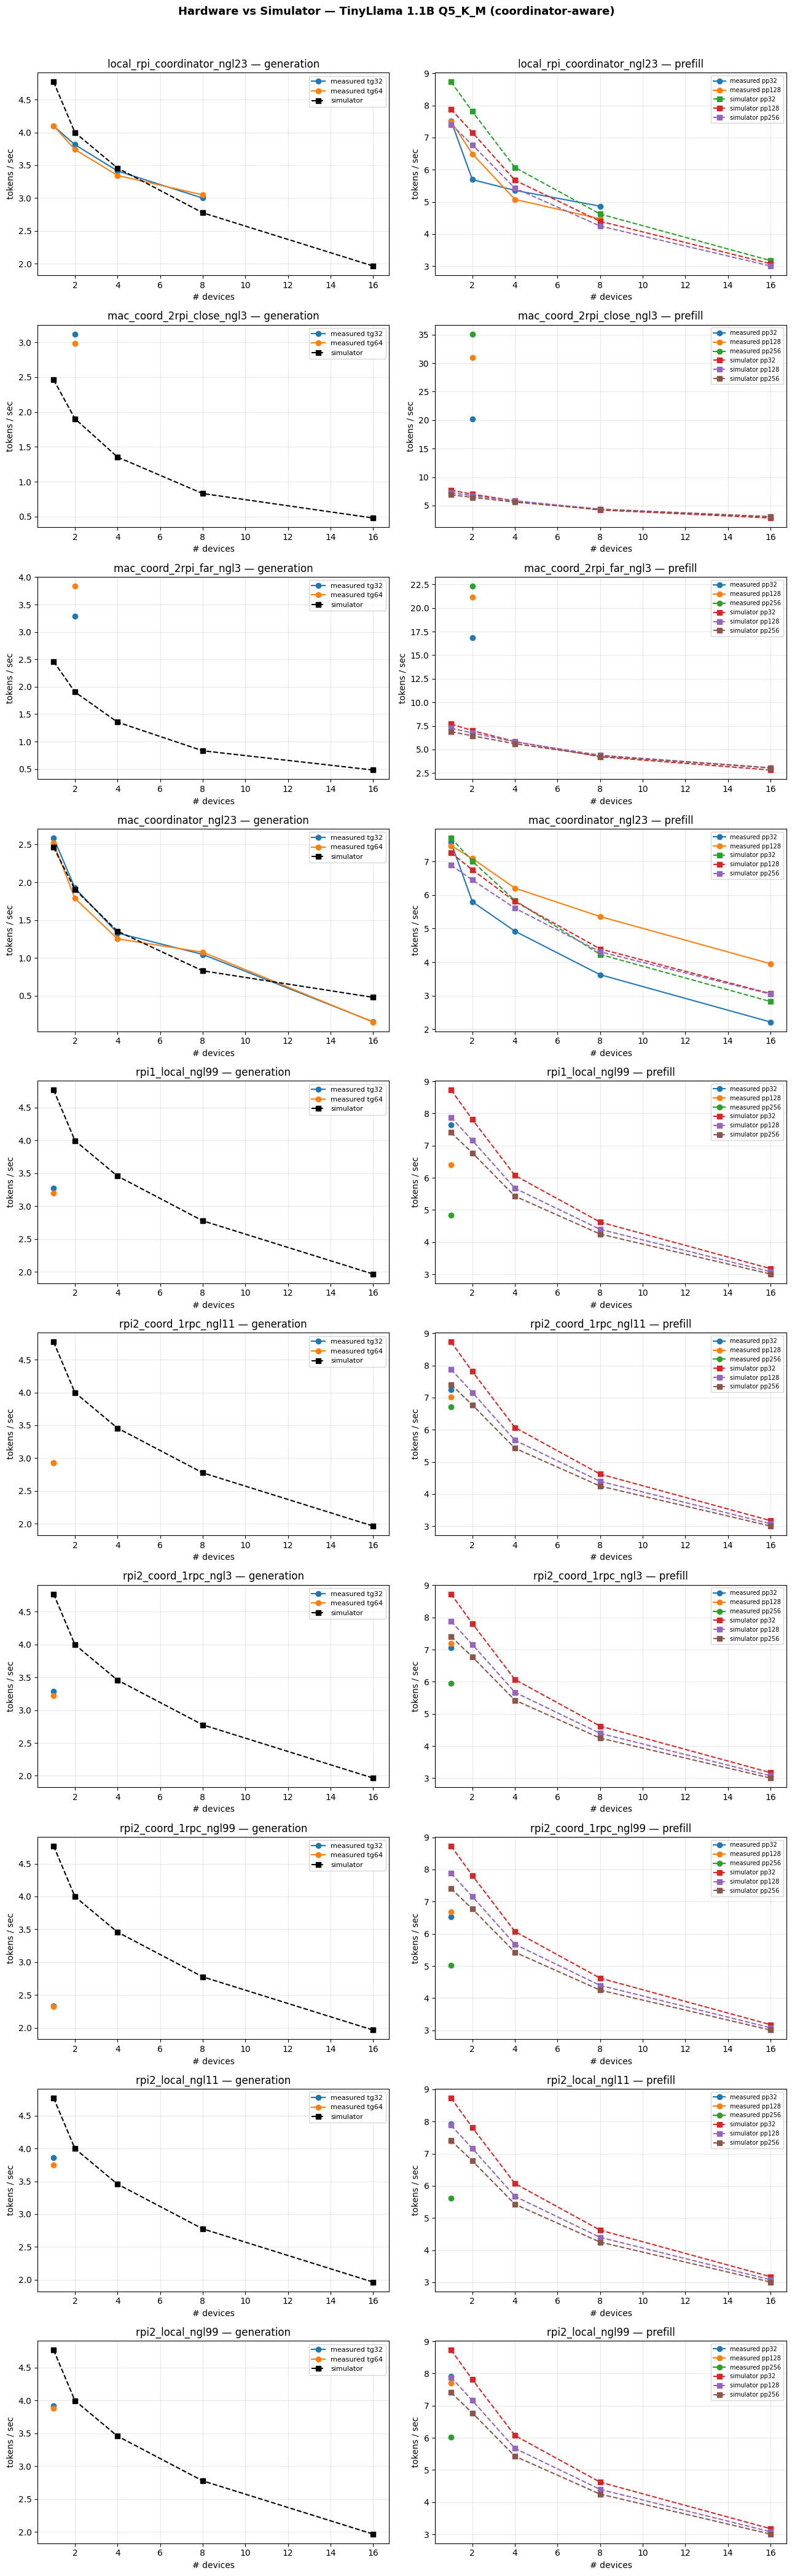


── Per-token generation latency (s/tok) — measured vs predicted ──


,scenario,coord,n_devices,n_gen,measured_s,predicted_s,ratio
0,local_rpi_coordinator_ngl23,mesh,1,32,0.244,0.210,1.16
1,local_rpi_coordinator_ngl23,mesh,1,64,0.244,0.210,1.16
2,local_rpi_coordinator_ngl23,mesh,2,32,0.262,0.250,1.05
3,local_rpi_coordinator_ngl23,mesh,2,64,0.267,0.250,1.07
4,local_rpi_coordinator_ngl23,mesh,4,32,0.293,0.289,1.01
5,local_rpi_coordinator_ngl23,mesh,4,64,0.299,0.289,1.03
6,local_rpi_coordinator_ngl23,mesh,8,32,0.333,0.360,0.93
7,local_rpi_coordinator_ngl23,mesh,8,64,0.328,0.360,0.91
8,mac_coord_2rpi_close_ngl3,Mac,2,32,0.321,0.525,0.61
9,mac_coord_2rpi_close_ngl3,Mac,2,64,0.336,0.525,0.64


In [9]:
if hw is None:
    print("Load measurement data first (cell above).")
else:
    # ── Network calibration knobs (see network.py) ──────────────────────
    # The driver placement matters: a Mac/client coordinator relays every
    # server<->server transfer across the AP; an on-mesh RPi coordinator keeps
    # it in the mesh. We predict BOTH and match each scenario to its coordinator
    # (name starts with "mac" -> client/Mac, else on-mesh RPi).
    # Calibrated against the measured sweeps (calibrate_rpc.py): this hop model takes
    # the RMS tok/s error from 49% -> 13% (excl. the n=16 AP contention cliff, which
    # no smooth law captures). Prefill no longer stays flat/rises with device count.
    RPC_EFFICIENCY      = 0.15   # η: llama.cpp RPC achieves ~15% of the iperf link
                                 # bandwidth (synchronous protocol, per-tensor
                                 # serialization, no compute/transfer overlap). THE
                                 # missing prefill-scaling term — universal across coords.
    AP_MSG_OVERHEAD_S   = 0.08   # fixed per-message RPC cost on an off-cluster (Mac/AP) hop
    MESH_MSG_OVERHEAD_S = 0.0    # on-mesh hop: fixed cost ~absorbed by link RTT (fit -> 0)
    HUB_BW_SHARE        = False  # superseded by RPC_EFFICIENCY (η already derates the shared
                                 # AP uplink); fit was better without this extra mechanism

    def _net_for_n(n, coordinator):
        devs = servers[:max(n, 1)]                 # cost-model-aware pool from §2
        # coordinator is a NAME (None => default off-cluster driver, else a server);
        # pass it to the constructor so the coordinator device is resolved consistently.
        net  = Network(servers=devs, coordinator_name=coordinator,
                       default_bw_mbps=50.0, default_rtt_ms=20.0)
        net.set_pairwise_links(filename="graph_partitioning/tests/pair_links_measured.csv")
        net.set_comm_config(communication_model=CommunicationModel.CLIENT_SERVER)
        net.msg_overhead_s   = AP_MSG_OVERHEAD_S if coordinator is None else MESH_MSG_OVERHEAD_S
        net.hub_bw_share     = HUB_BW_SHARE         # only bites for the off-cluster coordinator
        net.rpc_efficiency   = RPC_EFFICIENCY       # effective RPC bandwidth = η × link bw
        return net

    # coordinator per scenario: "mac*" -> client (None); everything else -> on-mesh RPi
    _coord_of = lambda scenario: None if scenario.startswith("mac") else servers[0].name
    COORDS    = {"driver": None, "mesh": servers[0].name}

    device_counts = sorted(hw["df"]["n_devices"].unique())
    n_prompt_vals = sorted(hw["pp"]["n_prompt"].unique())

    from graph_partitioning.policies.tensor import simulate_tensor_parallel
    # Each measured scenario carries a split_mode (row = tensor-parallel -sm row,
    # else pipeline/layer). Predict with the MATCHING policy, not always pipeline.
    scen_split = hw["df"].groupby("scenario")["split_mode"].first().to_dict()

    def _predict(coordinator, split):
        recs = []
        for n in device_counts:
            # -sm row can't split past num_kv_heads (TinyLlama=4): don't predict/plot beyond it.
            if split == "row" and n > TINYLLAMA.num_kv_heads:
                continue
            if n == 1:
                runner = simulate_single_node
            elif split == "row":
                runner = simulate_tensor_parallel      # -sm row: all-reduce per layer
            else:
                runner = simulate_pipeline
            for seq in n_prompt_vals:
                try:
                    r = runner(TINYLLAMA, _net_for_n(n, coordinator), seq_len=seq, gen_tokens=1)
                except Exception:
                    continue                            # e.g. TP requires n <= num_kv_heads
                recs.append({"n_devices": n, "type": "pp", "n_prompt": seq,
                             "sim_tps": seq / r["total_latency_s"],
                             "sim_latency_s": r["total_latency_s"]})
            try:
                r = runner(TINYLLAMA, _net_for_n(n, coordinator), seq_len=1, gen_tokens=1)
            except Exception:
                continue
            recs.append({"n_devices": n, "type": "tg",
                         "sim_tps": 1.0 / r["total_latency_s"],
                         "sim_latency_s": r["total_latency_s"]})
        return pd.DataFrame(recs)

    # Predict for every (coordinator, split_mode) present in the measurements.
    _splits = sorted(hw["df"]["split_mode"].unique())
    sim_by_key = {(lbl, sp): _predict(coord, sp)
                  for lbl, coord in COORDS.items() for sp in _splits}

    def _sim_for(scenario):
        coord = "driver" if scenario.startswith("mac") else "mesh"
        return sim_by_key[(coord, scen_split.get(scenario, "layer"))]

    plt.close("all")

    # ── Per-scenario panels (sim curve matched to the scenario's coordinator) ──
    scenarios = sorted(hw["df"]["scenario"].unique())
    print(f"Plotting {len(scenarios)} scenario(s):")
    for s in scenarios:
        print(f"  {s}  ->  {'off-cluster' if s.startswith('mac') else 'on-mesh RPi'} coordinator")
    print()

    n_scen = len(scenarios)
    fig, axes = plt.subplots(n_scen, 2, figsize=(13, 4.2 * n_scen), squeeze=False)
    for row, scenario in enumerate(scenarios):
        ax_tg, ax_pp = axes[row]
        sim = _sim_for(scenario)

        sub_tg = hw["tg"][hw["tg"]["scenario"] == scenario]
        for n_gen, grp in sub_tg.groupby("n_gen"):
            ax_tg.plot(grp["n_devices"], grp["tg_tps"], marker="o", label=f"measured tg{n_gen}")
        sim_tg = sim[sim["type"] == "tg"]
        ax_tg.plot(sim_tg["n_devices"], sim_tg["sim_tps"], marker="s", linestyle="--",
                   color="black", label="simulator")
        ax_tg.set(title=f"{scenario} — generation", xlabel="# devices", ylabel="tokens / sec")
        ax_tg.grid(True, alpha=0.3); ax_tg.legend(fontsize=8)

        sub_pp = hw["pp"][hw["pp"]["scenario"] == scenario]
        for seq, grp in sub_pp.groupby("n_prompt"):
            ax_pp.plot(grp["n_devices"], grp["pp_tps"], marker="o", label=f"measured pp{seq}")
        for seq in n_prompt_vals:
            sim_pp = sim[(sim["type"] == "pp") & (sim["n_prompt"] == seq)]
            ax_pp.plot(sim_pp["n_devices"], sim_pp["sim_tps"], marker="s", linestyle="--",
                       label=f"simulator pp{seq}")
        ax_pp.set(title=f"{scenario} — prefill", xlabel="# devices", ylabel="tokens / sec")
        ax_pp.grid(True, alpha=0.3); ax_pp.legend(fontsize=7)

    fig.suptitle("Hardware vs Simulator — TinyLlama 1.1B Q5_K_M (coordinator-aware)",
                 fontsize=13, fontweight="bold", y=1 - 0.12 / fig.get_figheight())
    fig.tight_layout(rect=[0, 0, 1, 1 - 0.5 / fig.get_figheight()])  # reserve room for suptitle
    if SAVE_FIGS:
        out_dir = f"{OUTPUT_ROOT}/hw_comparison"; os.makedirs(out_dir, exist_ok=True)
        fig.savefig(f"{out_dir}/hw_vs_sim_per_scenario.pdf", bbox_inches="tight")
    display(fig); plt.close(fig)

    # ── Per-token decode latency table — measured vs predicted ──────────
    print("\n── Per-token generation latency (s/tok) — measured vs predicted ──")
    rows = []
    for scenario in scenarios:
        sim = _sim_for(scenario)
        sub_tg = hw["tg"][hw["tg"]["scenario"] == scenario]
        for _, m in sub_tg.iterrows():
            pred = sim[(sim["type"] == "tg") &
                       (sim["n_devices"] == m["n_devices"])]["sim_latency_s"].values
            if not len(pred):
                continue
            meas_per_tok = 1.0 / float(m["tg_tps"])
            rows.append({"scenario": scenario,
                         "coord": "Mac" if scenario.startswith("mac") else "mesh",
                         "n_devices": int(m["n_devices"]), "n_gen": int(m["n_gen"]),
                         "measured_s": round(meas_per_tok, 3),
                         "predicted_s": round(float(pred[0]), 3),
                         "ratio": round(meas_per_tok / float(pred[0]), 2)})
    display(pd.DataFrame(rows))


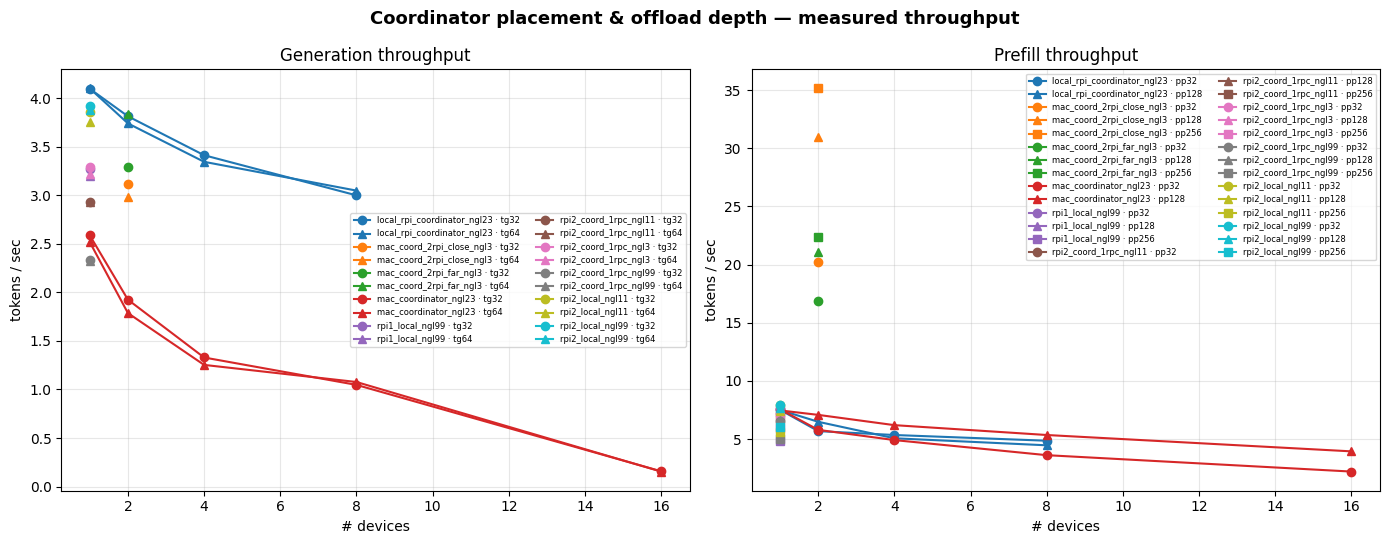


── tg32 throughput (t/s) by scenario × n_devices ──


scenario,local_rpi_coordinator_ngl23,mac_coord_2rpi_close_ngl3,mac_coord_2rpi_far_ngl3,mac_coordinator_ngl23,rpi1_local_ngl99,rpi2_coord_1rpc_ngl11,rpi2_coord_1rpc_ngl3,rpi2_coord_1rpc_ngl99,rpi2_local_ngl11,rpi2_local_ngl99
n_devices,,,,,,,,,,
1,4.096,NaN,NaN,2.586,3.27,2.93,3.29,2.33,3.86,3.92
2,3.814,3.12,3.29,1.925,NaN,NaN,NaN,NaN,NaN,NaN
4,3.413,NaN,NaN,1.329,NaN,NaN,NaN,NaN,NaN,NaN
8,2.999,NaN,NaN,1.047,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,0.157,NaN,NaN,NaN,NaN,NaN,NaN



Local-RPi-coord vs Mac-coord (tg32 throughput ratio):
  n_devices=  1:  1.58× (faster with local RPi coord)
  n_devices=  2:  1.98× (faster with local RPi coord)
  n_devices=  4:  2.57× (faster with local RPi coord)
  n_devices=  8:  2.86× (faster with local RPi coord)


In [10]:
if hw is None or len(hw["df"]["scenario"].unique()) < 2:
    print("Need at least two scenarios for a cross-scenario comparison.")
else:
    # ── Cross-scenario throughput at a fixed (n_gen=32, n_prompt=128) ──
    # One marker per (scenario, n_devices); colour groups by coordinator.
    fig, (ax_tg, ax_pp) = plt.subplots(1, 2, figsize=(14, 5.5))

    cmap = plt.get_cmap("tab10")
    scen_color = {s: cmap(i % 10) for i, s in enumerate(sorted(hw["df"]["scenario"].unique()))}

    for scenario, color in scen_color.items():
        sub_tg = hw["tg"][hw["tg"]["scenario"] == scenario]
        for n_gen, grp in sub_tg.groupby("n_gen"):
            marker = "o" if n_gen == 32 else "^" if n_gen == 64 else "s"
            ax_tg.plot(grp["n_devices"], grp["tg_tps"],
                       marker=marker, color=color,
                       label=f"{scenario} · tg{n_gen}", linewidth=1.5)

        sub_pp = hw["pp"][hw["pp"]["scenario"] == scenario]
        for seq, grp in sub_pp.groupby("n_prompt"):
            marker = "o" if seq == 32 else "^" if seq == 128 else "s"
            ax_pp.plot(grp["n_devices"], grp["pp_tps"],
                       marker=marker, color=color,
                       label=f"{scenario} · pp{seq}", linewidth=1.5)

    for ax, title in [(ax_tg, "Generation throughput"),
                      (ax_pp, "Prefill throughput")]:
        ax.set(title=title, xlabel="# devices", ylabel="tokens / sec")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6, loc="best", ncol=2)

    fig.suptitle("Coordinator placement & offload depth — measured throughput",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    if SAVE_FIGS:
        out_dir = f"{OUTPUT_ROOT}/hw_comparison"
        os.makedirs(out_dir, exist_ok=True)
        fig.savefig(f"{out_dir}/coord_placement.pdf", bbox_inches="tight")
    display(fig)          # display() renders inline regardless of backend (plt.show() fails under Agg)
    plt.close(fig)

    # ── Pivot table: tg32 throughput by (n_devices, scenario) ──
    print("\n── tg32 throughput (t/s) by scenario × n_devices ──")
    pivot_tg = (hw["tg"][hw["tg"]["n_gen"] == 32]
                .pivot_table(index="n_devices", columns="scenario",
                             values="tg_tps", aggfunc="mean"))
    display(pivot_tg.round(3))

    # If both Mac-coord and local-RPi-coord are present at -ngl 23 (the
    # full-offload sweeps), report the ratio — that's the headline number.
    mac_col   = "mac_coordinator_ngl23"
    local_col = "local_rpi_coordinator_ngl23"
    if {mac_col, local_col}.issubset(pivot_tg.columns):
        ratio = (pivot_tg[local_col] / pivot_tg[mac_col]).dropna()
        print(f"\nLocal-RPi-coord vs Mac-coord (tg32 throughput ratio):")
        for n, r in ratio.items():
            print(f"  n_devices={int(n):>3d}:  {r:.2f}× "
                  f"({'faster' if r > 1 else 'slower'} with local RPi coord)")